In [1]:
# ==============================================================================
# CELL 1: IMPORTS & SETUP
# ==============================================================================
import pandas as pd
import warnings
warnings.filterwarnings('ignore') # Opcional: silencia avisos do scikit-learn
import sys
from pathlib import Path

current_path = Path.cwd()
PROJECT_ROOT = None

for p in [current_path, current_path.parent, current_path.parent.parent]:
    if (p / "rainfall_acoustic_classification").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT)) # insert(0) garante prioridade absoluta
    print(f"✅ Raiz do projeto adicionada ao sys.path: {PROJECT_ROOT}")
else:
    print("❌ ERRO: Não foi possível encontrar a raiz do projeto.")

# Importando a sua Arquitetura de Alto Nível
from rainfall_acoustic_classification.visualization.engine import VisualizationEngine
from rainfall_acoustic_classification.feature_engineering import (
    ExperimentConfig, ExperimentCreator, build_vector_selector, VectorSelectorConfig
)
# Inicializa o Motor Visual (Cores e Estilos Qualis A1)
viz_engine = VisualizationEngine()

✅ Raiz do projeto adicionada ao sys.path: c:\Users\ggrmi\Documents\SI-Tarcisio\Sound-of-Rainfall\RAC-semiurban-forest-ML-2026


In [2]:
# ==============================================================================
# CELL 2: DATA INGESTION (COLOQUE SEUS CAMINHOS REAIS AQUI)
# ==============================================================================
CAMINHO_TREINO = PROJECT_ROOT / "data" / "processed" / "Chavascal" / "chavascal_train_metrics_patched.csv"
CAMINHO_VAL = PROJECT_ROOT / "data" / "processed" / "Chavascal" / "chavascal_val_metrics_patched.csv"

# Carrega os dados reais extraídos
df_train_raw = pd.read_csv(CAMINHO_TREINO)
df_val_raw = pd.read_csv(CAMINHO_VAL)

print(f"Treino carregado: {df_train_raw.shape}")
print(f"Validação carregada: {df_val_raw.shape}")

mapa_binario_real = {
    'no-rain': 'Dry', 
    'light': 'Wet', 'moderate': 'Wet', 
    'heavy': 'Wet', 'violent': 'Wet'
}

mapa_3_classes_real = {
    'no-rain': 'No Rain', 
    'light': 'Light/Moderate', 'moderate': 'Light/Moderate', 
    'heavy': 'Heavy/Violent', 'violent': 'Heavy/Violent'
}
mapa_5_classes_real = {
    'no-rain': 'No Rain', 
    'light': 'Light', 'moderate': 'Moderate', 
    'heavy': 'Heavy', 'violent': 'Violent'
}


# Configuração do Experimento (Ex: 3-Classes)
exp_config = ExperimentConfig(content='dry/wet', granularity=2, custom_mapping=mapa_binario_real)

# O ExperimentCreator separa o X (features matemáticas), y (alvos) e meta (metadados inúteis)
X_train_raw, y_train, meta_train = ExperimentCreator.apply_experiment_rules(
    *ExperimentCreator.extract_X_y_meta(df_train_raw, exp_config), exp_config
)

X_val_raw, y_val, meta_val = ExperimentCreator.apply_experiment_rules(
    *ExperimentCreator.extract_X_y_meta(df_val_raw, exp_config), exp_config
)

print(f"Classes após mapeamento (Treino): {y_train.unique()}")

Treino carregado: (4037, 113)
Validação carregada: (407, 112)
19:12:33 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 2
19:12:33 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 2
Classes após mapeamento (Treino): ['Dry' 'Wet']


In [3]:
# ==============================================================================
# CELL 3: FEATURE SELECTION PIPELINE
# ==============================================================================
# Configura o seletor (n_jobs=-1 já usa todos os núcleos seguros da máquina)
selector_config = VectorSelectorConfig(corr_threshold=0.85, rf_n_estimators=100, fisher_percentile=60)
seletor_pipeline = build_vector_selector(selector_config)

print("Iniciando Seleção de Features (Apenas no Treino para evitar Data Leakage)...")

# Ajusta (aprende) no treino e transforma
X_train_final = seletor_pipeline.fit_transform(X_train_raw, y_train)

# Apenas transforma a validação cegamente
X_val_final = seletor_pipeline.transform(X_val_raw)

print(f"Features Originais: {X_train_raw.shape[1]} -> Retidas: {X_train_final.shape[1]}")

Iniciando Seleção de Features (Apenas no Treino para evitar Data Leakage)...
19:12:37 - [FeatureSelector] - INFO - Collinearity filter established. Dropping 28 features.
Features Originais: 91 -> Retidas: 7


In [4]:
# ==============================================================================
# CELL 8: EXPORTAÇÃO DOS ARTEFATOS (A Ponte para a Modelagem)
# ==============================================================================
import joblib
from pathlib import Path

# Cria a pasta de artefatos se ela não existir
pasta_artefatos = Path("./artefatos_ml")
pasta_artefatos.mkdir(exist_ok=True)

print("1. Salvando as Matrizes de Dados com as 7 Features...")
# Salva o X e junta com o y para não perdermos o alinhamento das linhas
X_train_final.assign(label=y_train).to_csv(pasta_artefatos / "treino_selecionado.csv", index=False)
X_val_final.assign(label=y_val).to_csv(pasta_artefatos / "val_selecionado.csv", index=False)

print("2. Congelando o Cérebro do Pipeline (Joblib)...")
# Salvar o pipeline é vital! Quando o seu Dataset de Teste chegar, 
# ele precisará passar pelo SafeImputer e pelo scaler EXATOS que treinamos aqui.
joblib.dump(seletor_pipeline, pasta_artefatos / "seletor_pipeline.pkl")

print(f"✅ Sucesso! Dados prontos na pasta: {pasta_artefatos.resolve()}")

1. Salvando as Matrizes de Dados com as 7 Features...
2. Congelando o Cérebro do Pipeline (Joblib)...
✅ Sucesso! Dados prontos na pasta: /Users/fabiomachadomilan/Documents/GitHub/RAC-semiurban-forest-ML-2026/notebooks/Chavascal/artefatos_ml


Iniciando auditoria visual. Features retidas: 7

2. Gerando Matriz de Correlação Completa (Destaque para as Sobreviventes)...
18:41:58 - [FeaturePlots] - INFO - Generating Correlation Heatmap...


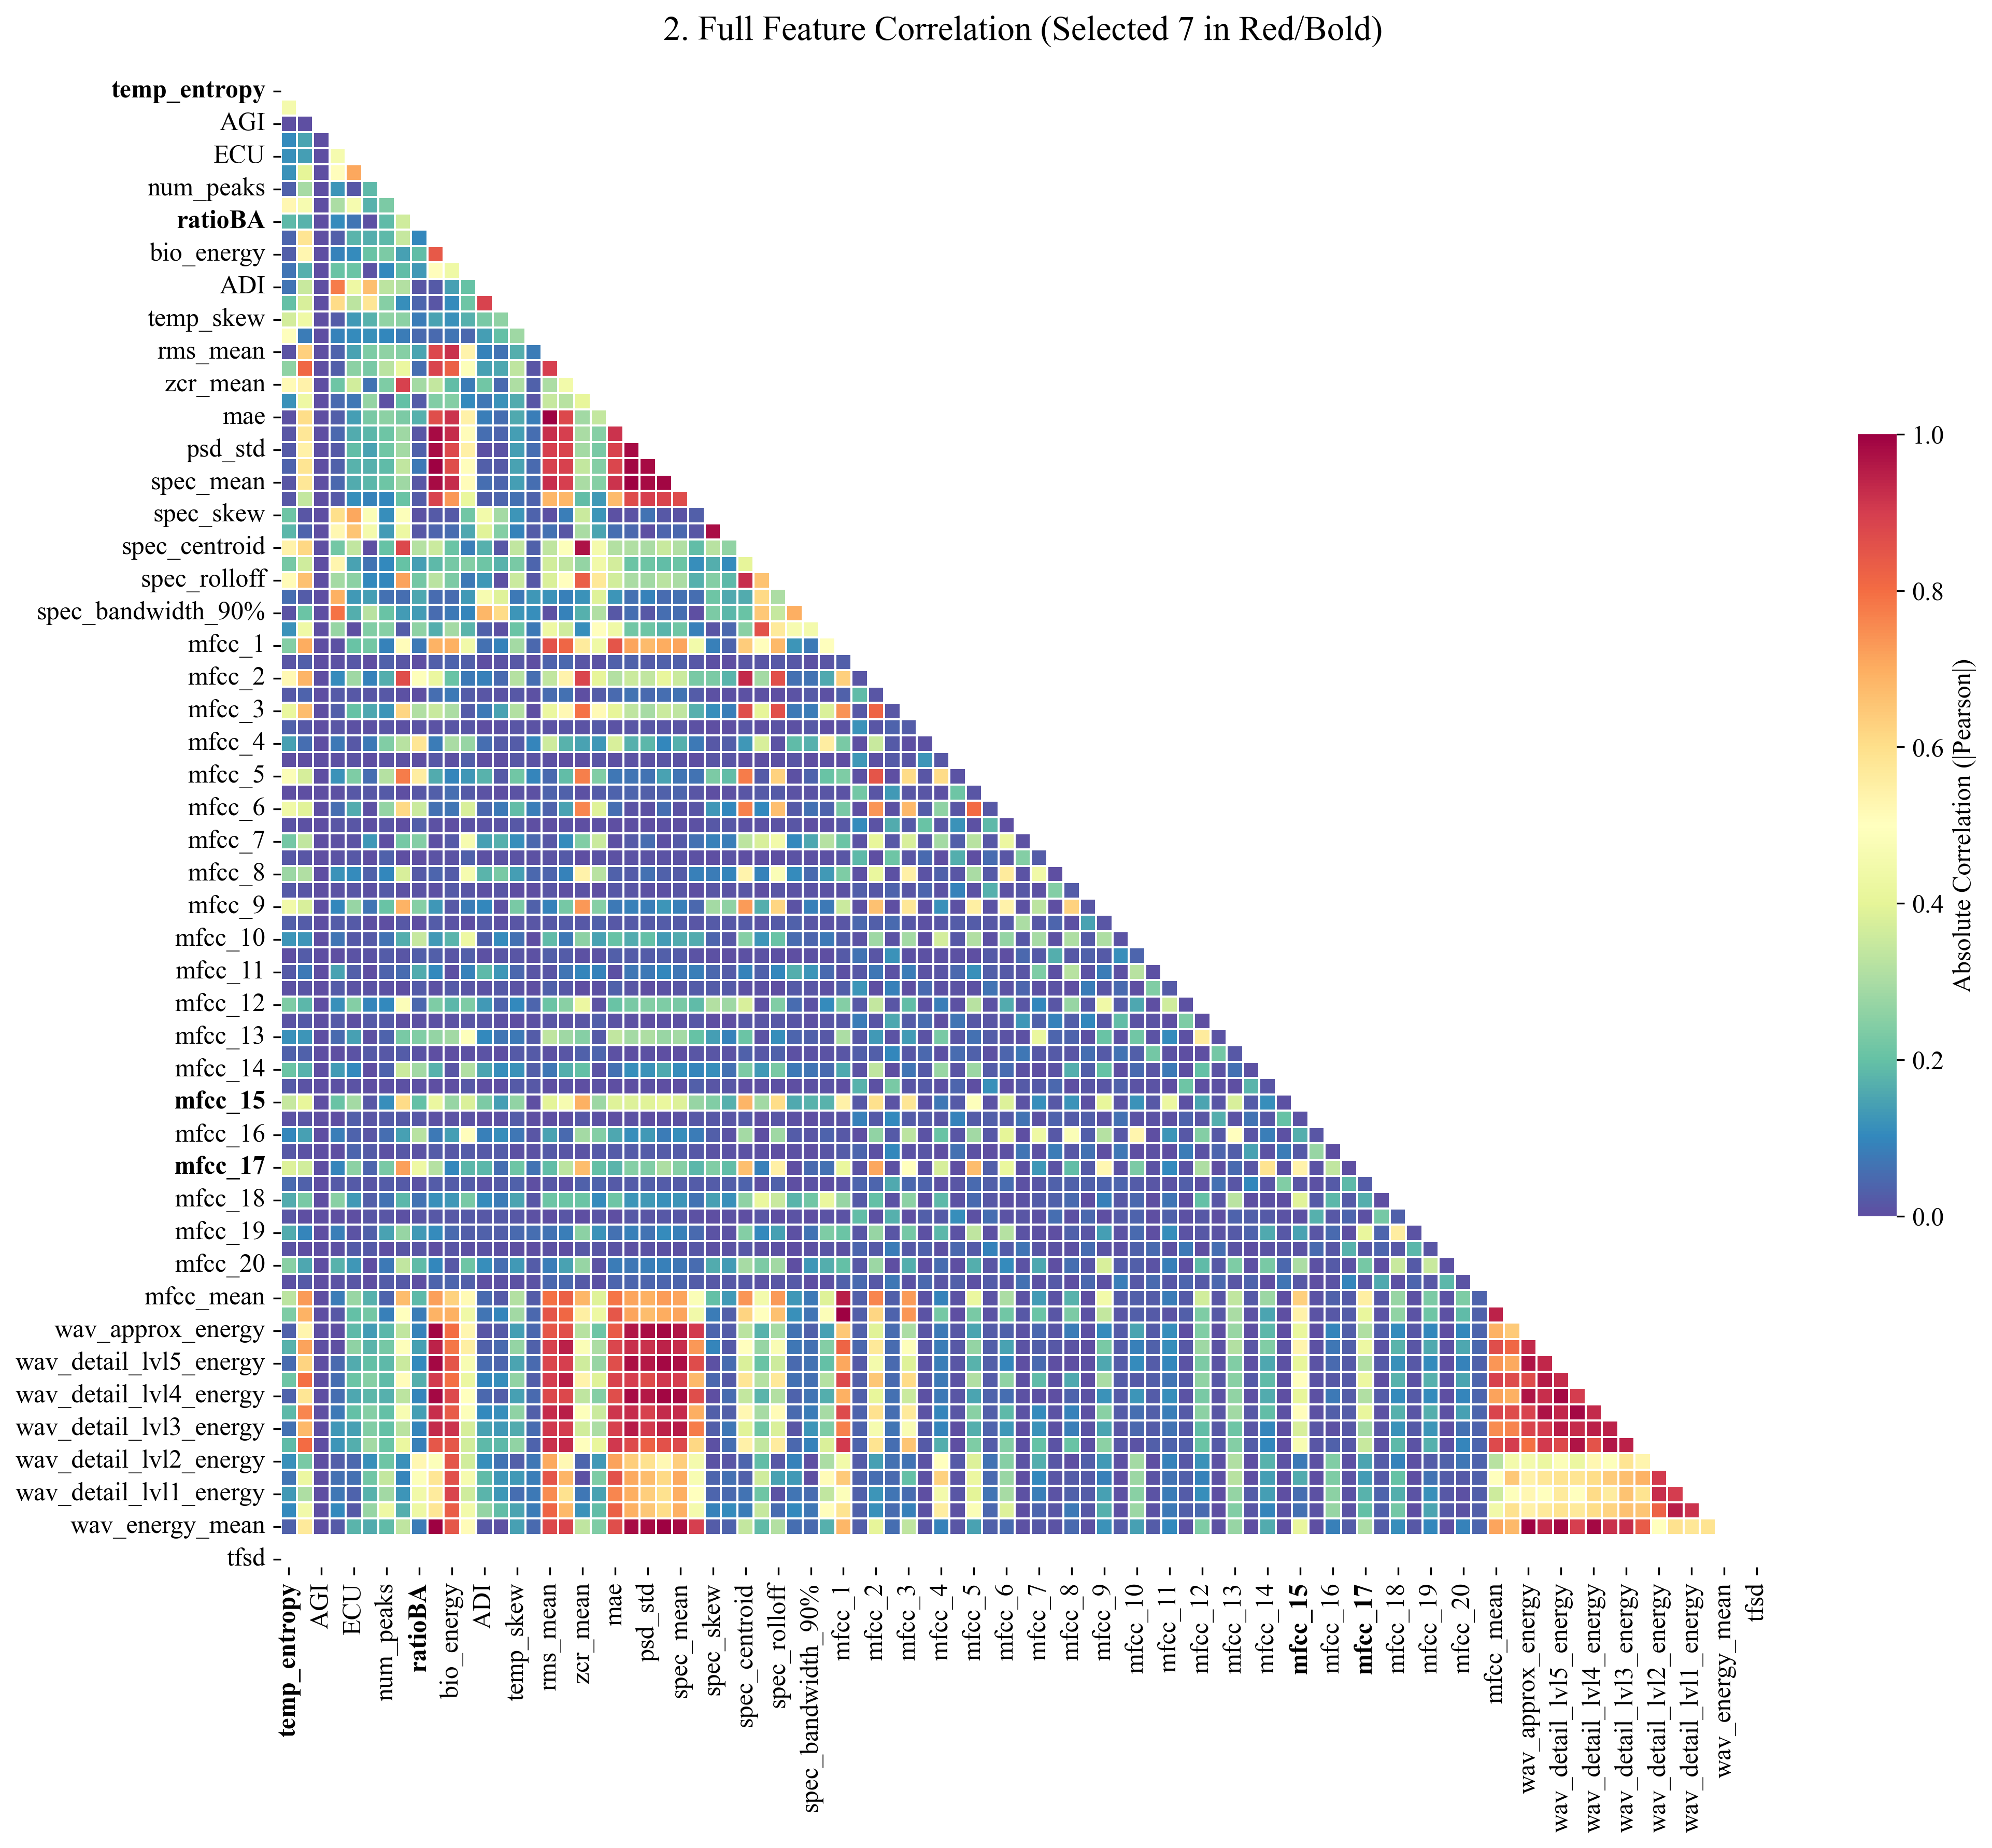


1. Extraindo o Coeficiente de Fisher (Poder de Separação Isolada)...
18:42:05 - [FeaturePlots] - INFO - Generating Fisher Score Plot (Top 20)...


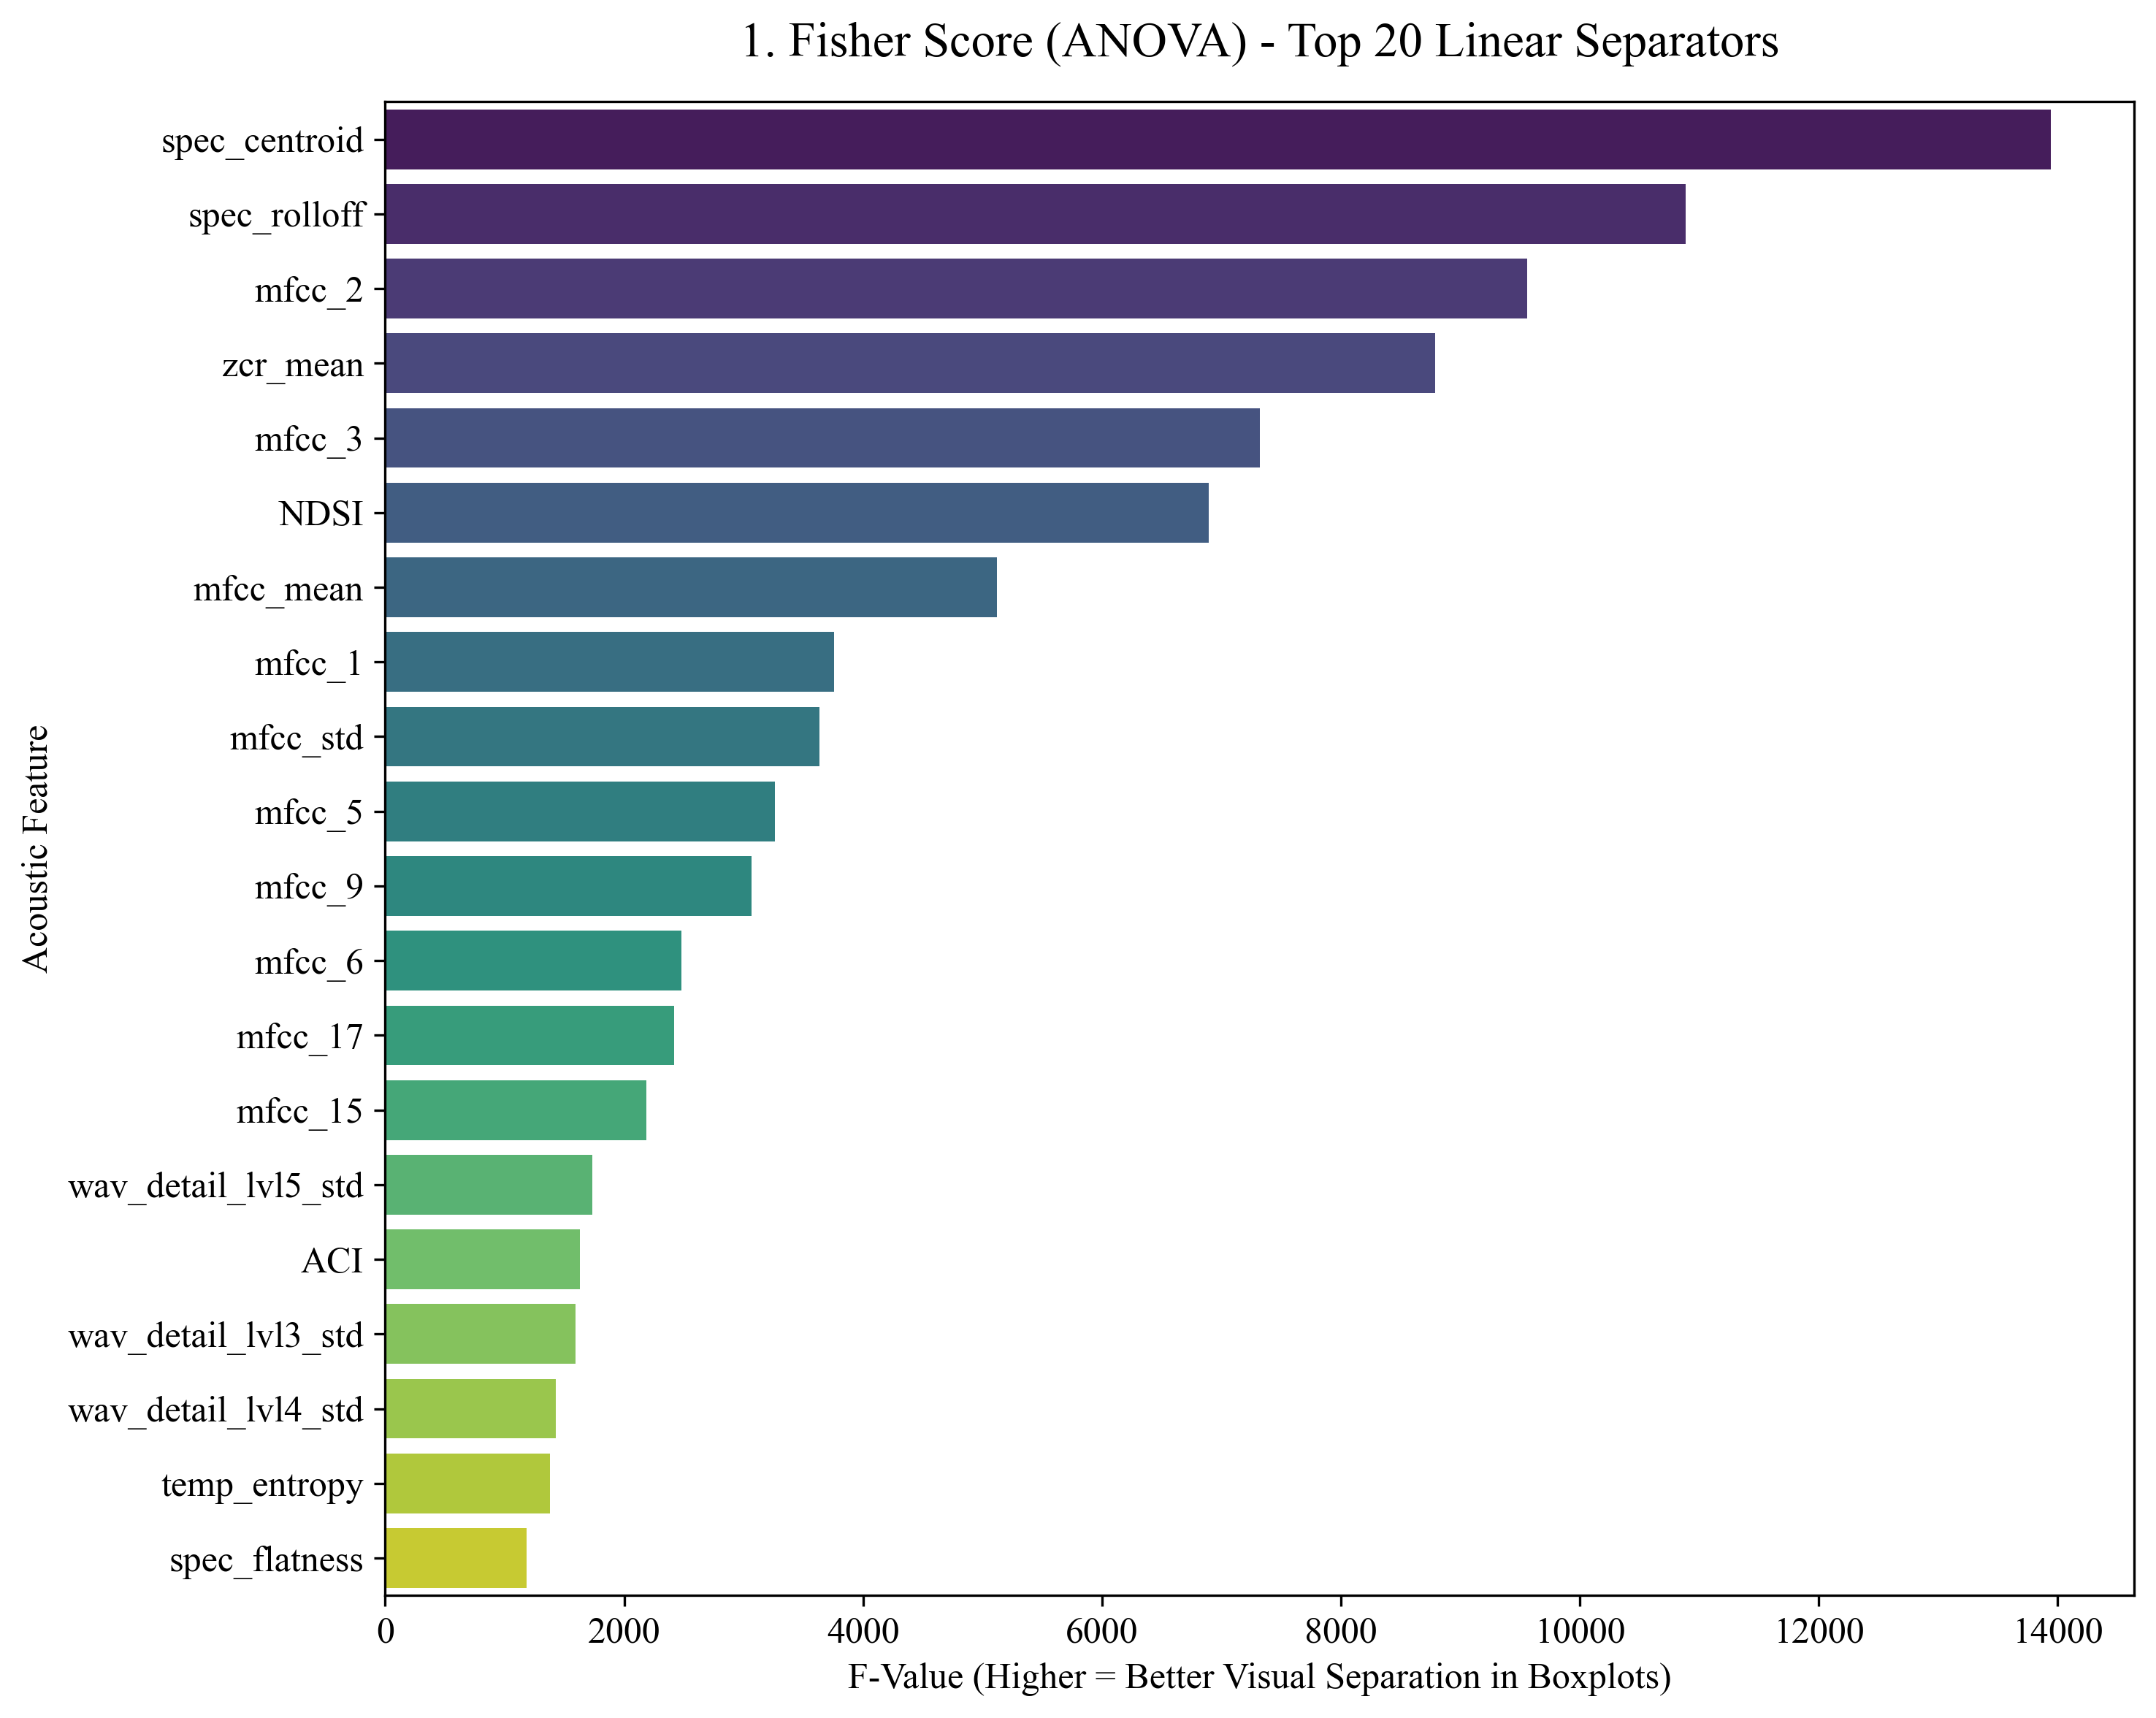


3. Extraindo a Importância Gini do Random Forest...
18:42:09 - [FeaturePlots] - INFO - Generating Feature Importance Plot (Top 25)...


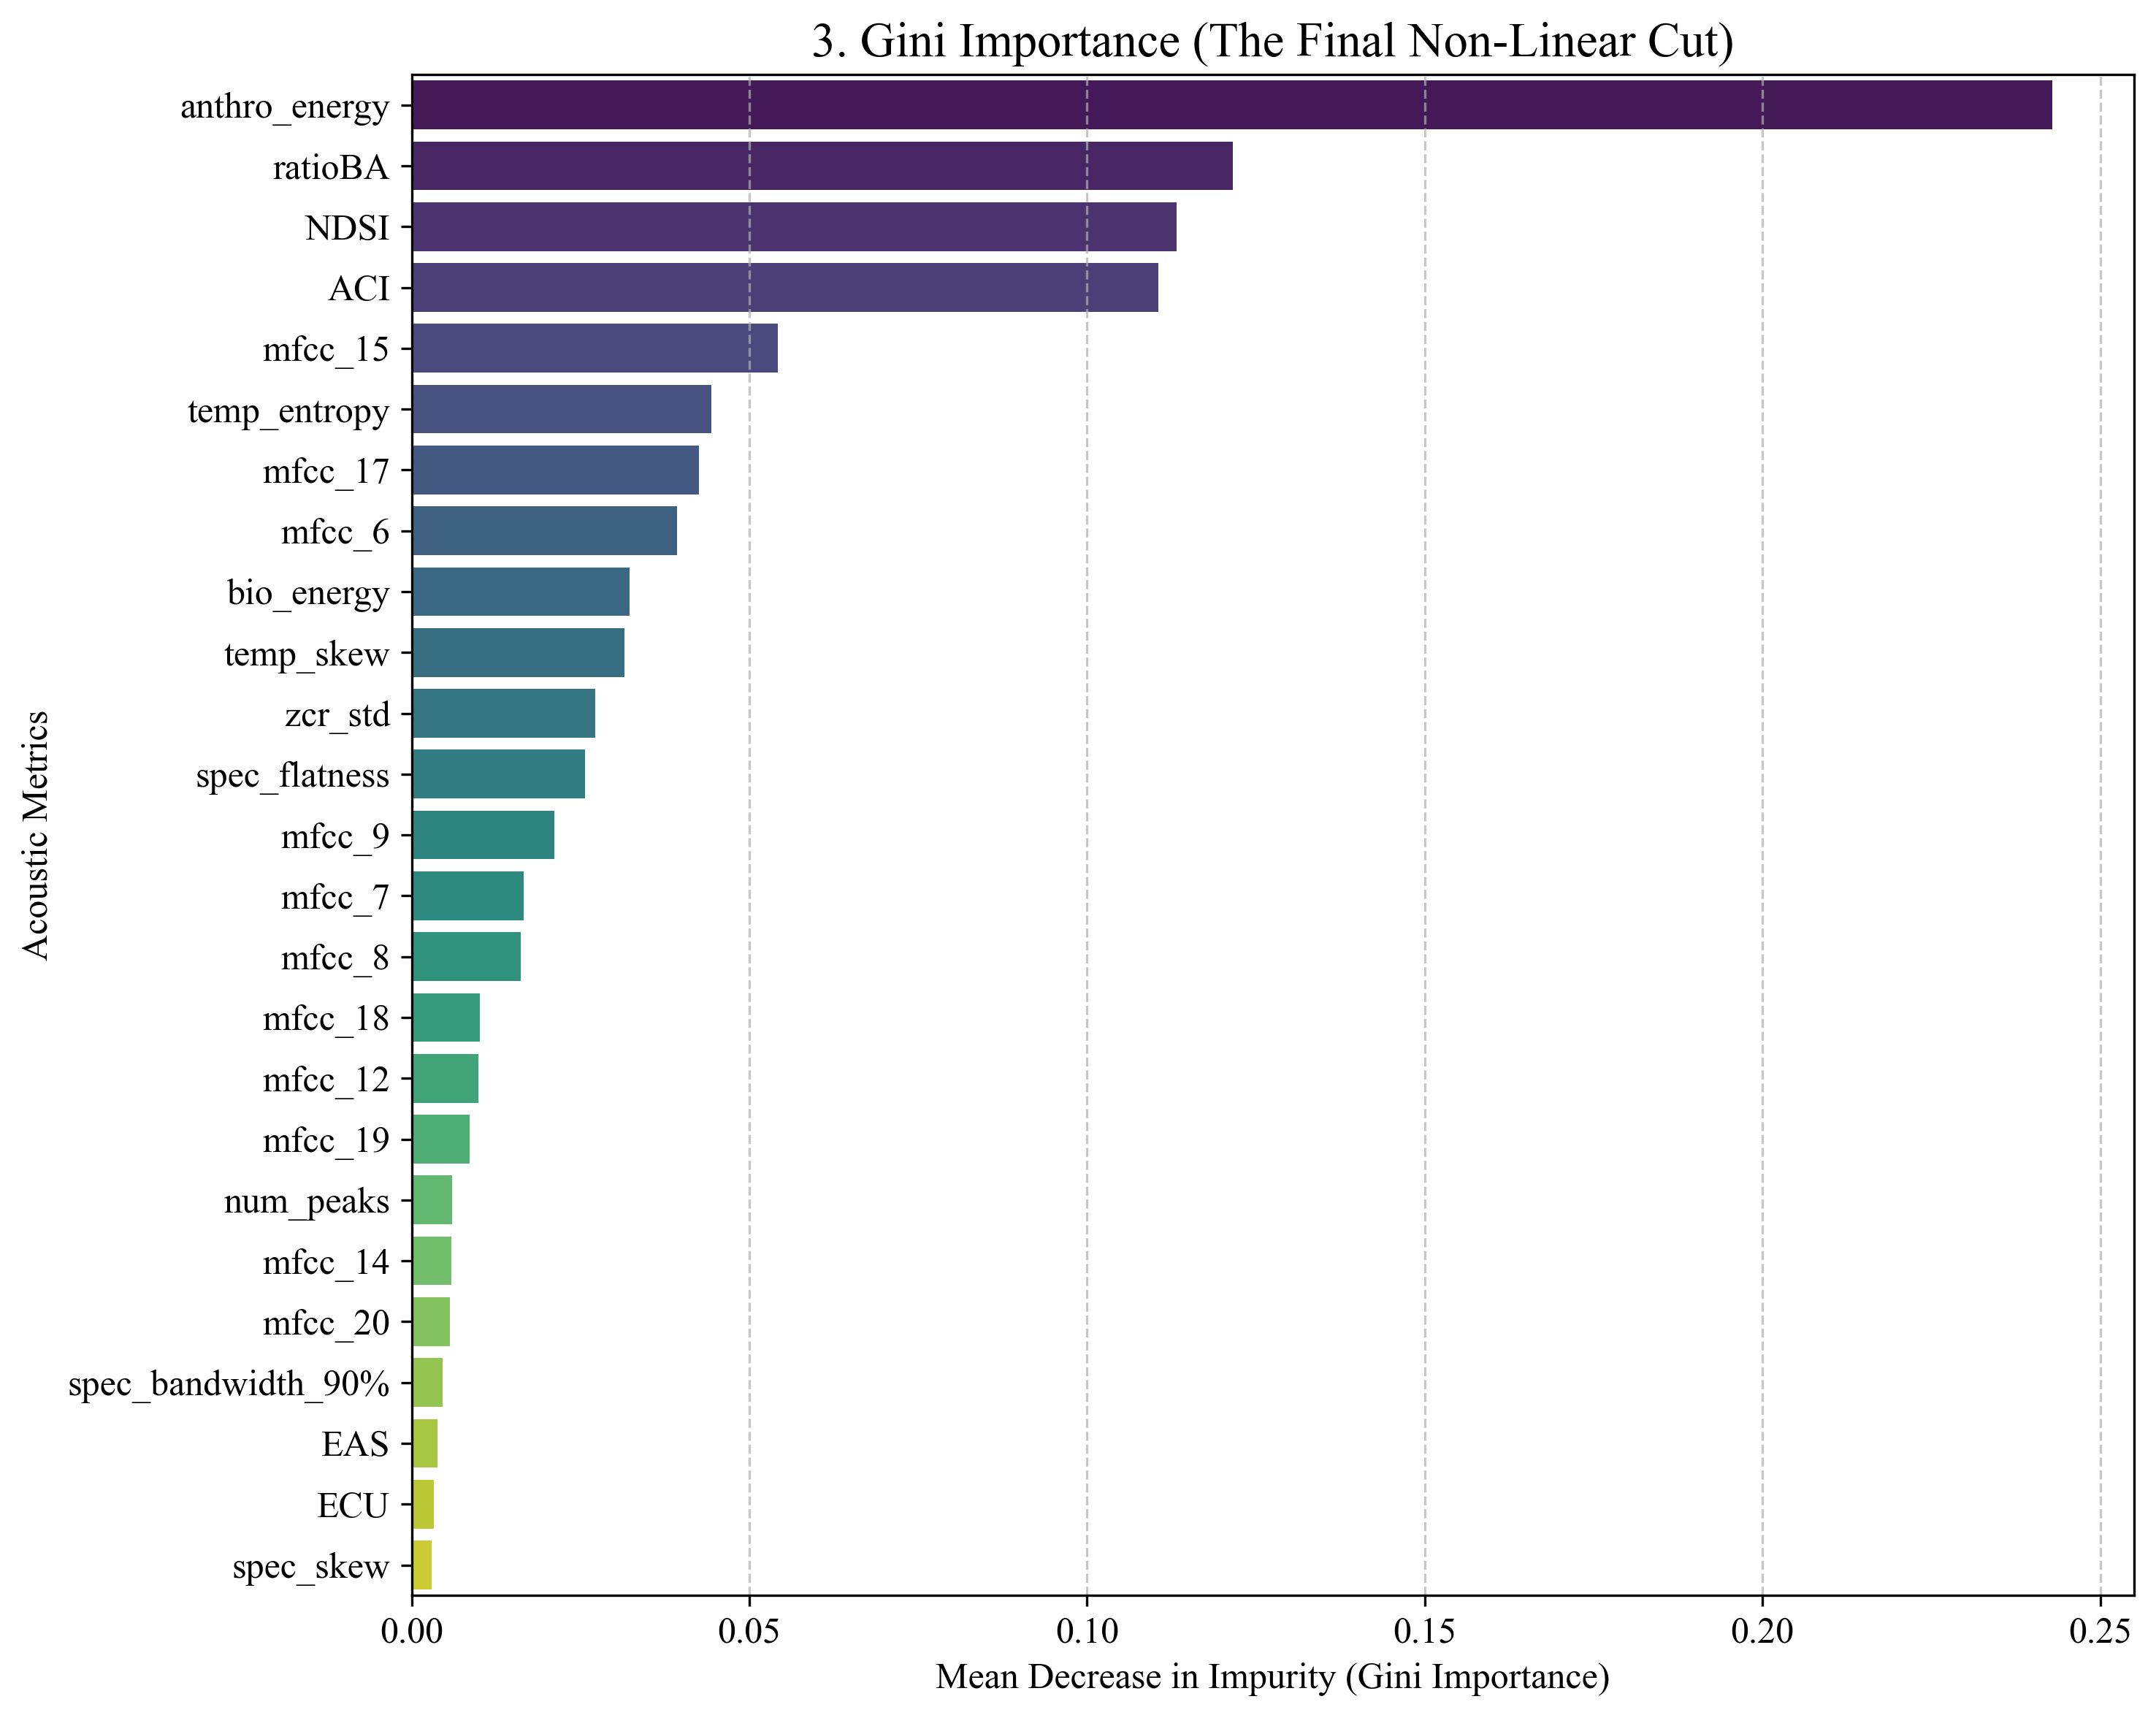


4. Cruzando Fisher vs Gini (A Justificativa da Seleção)...
18:42:13 - [FeaturePlots] - INFO - Generating Selection Rationale Plot...


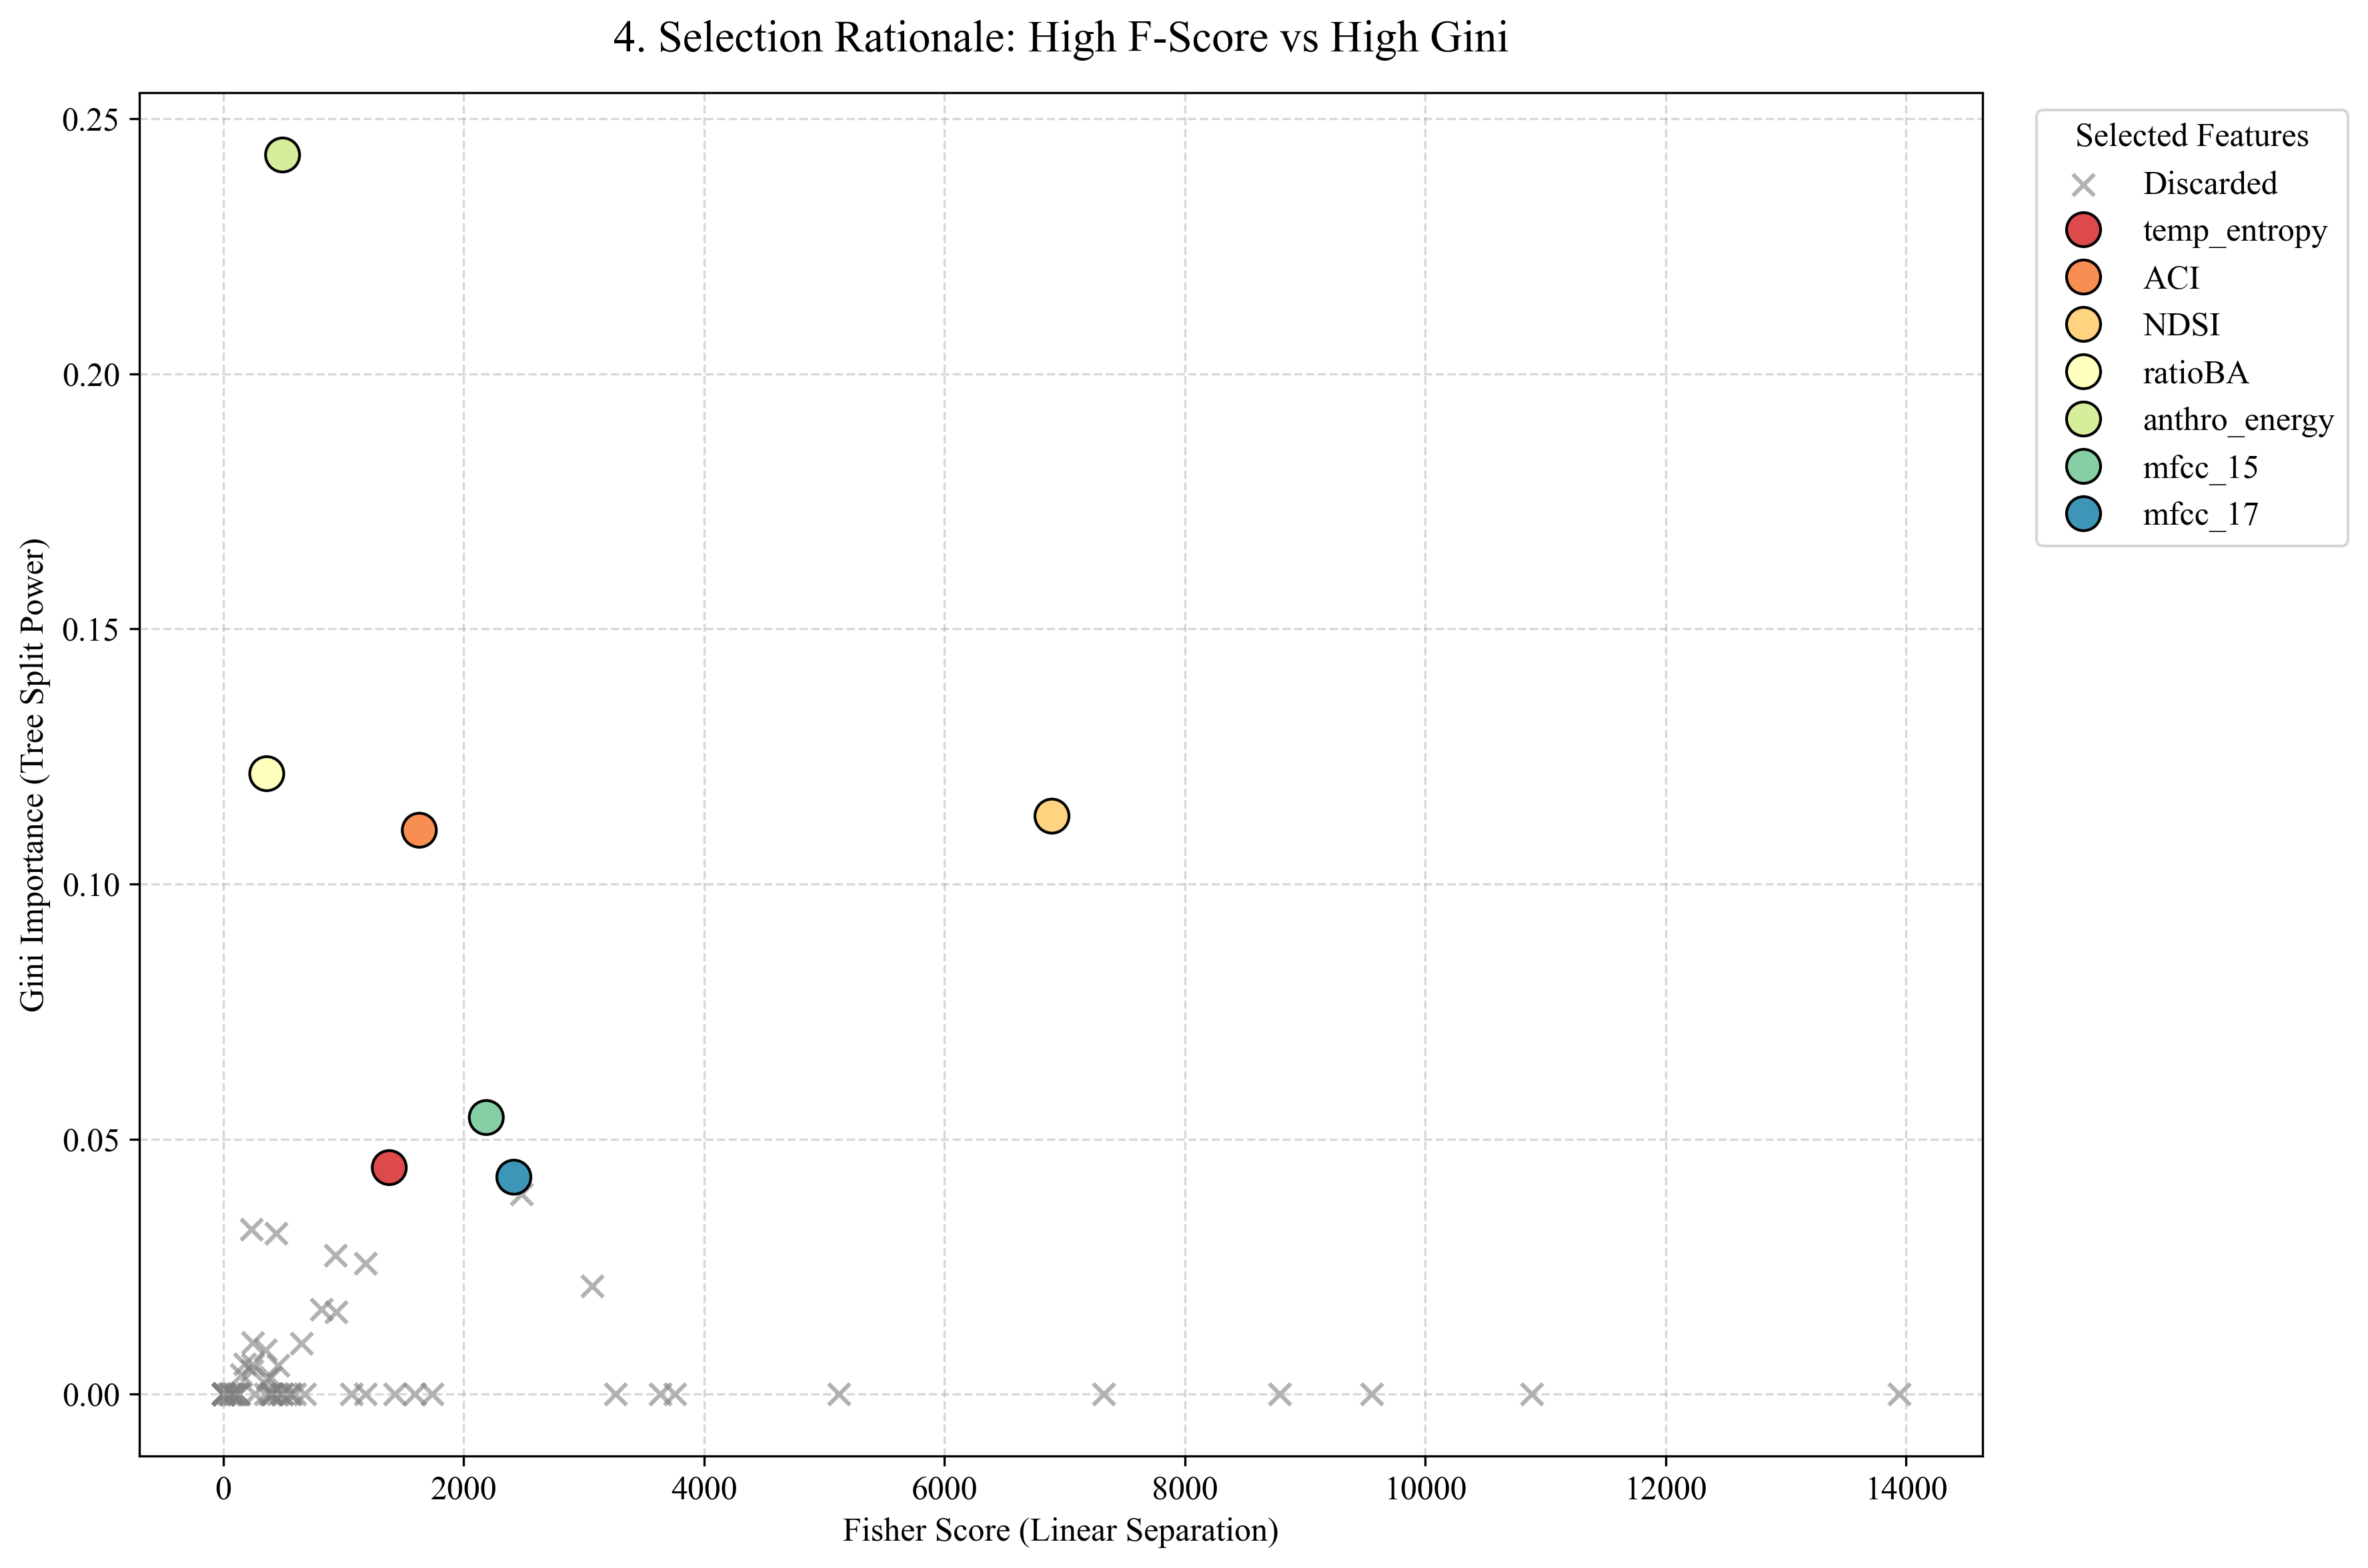


5. Gerando os 7 Boxplots Definitivos...
Dica: Estas 7 features são matematicamente únicas e possuem o maior poder discriminativo conjunto.
18:42:16 - [FeaturePlots] - INFO - Generating Individual Boxplots for 7 features...


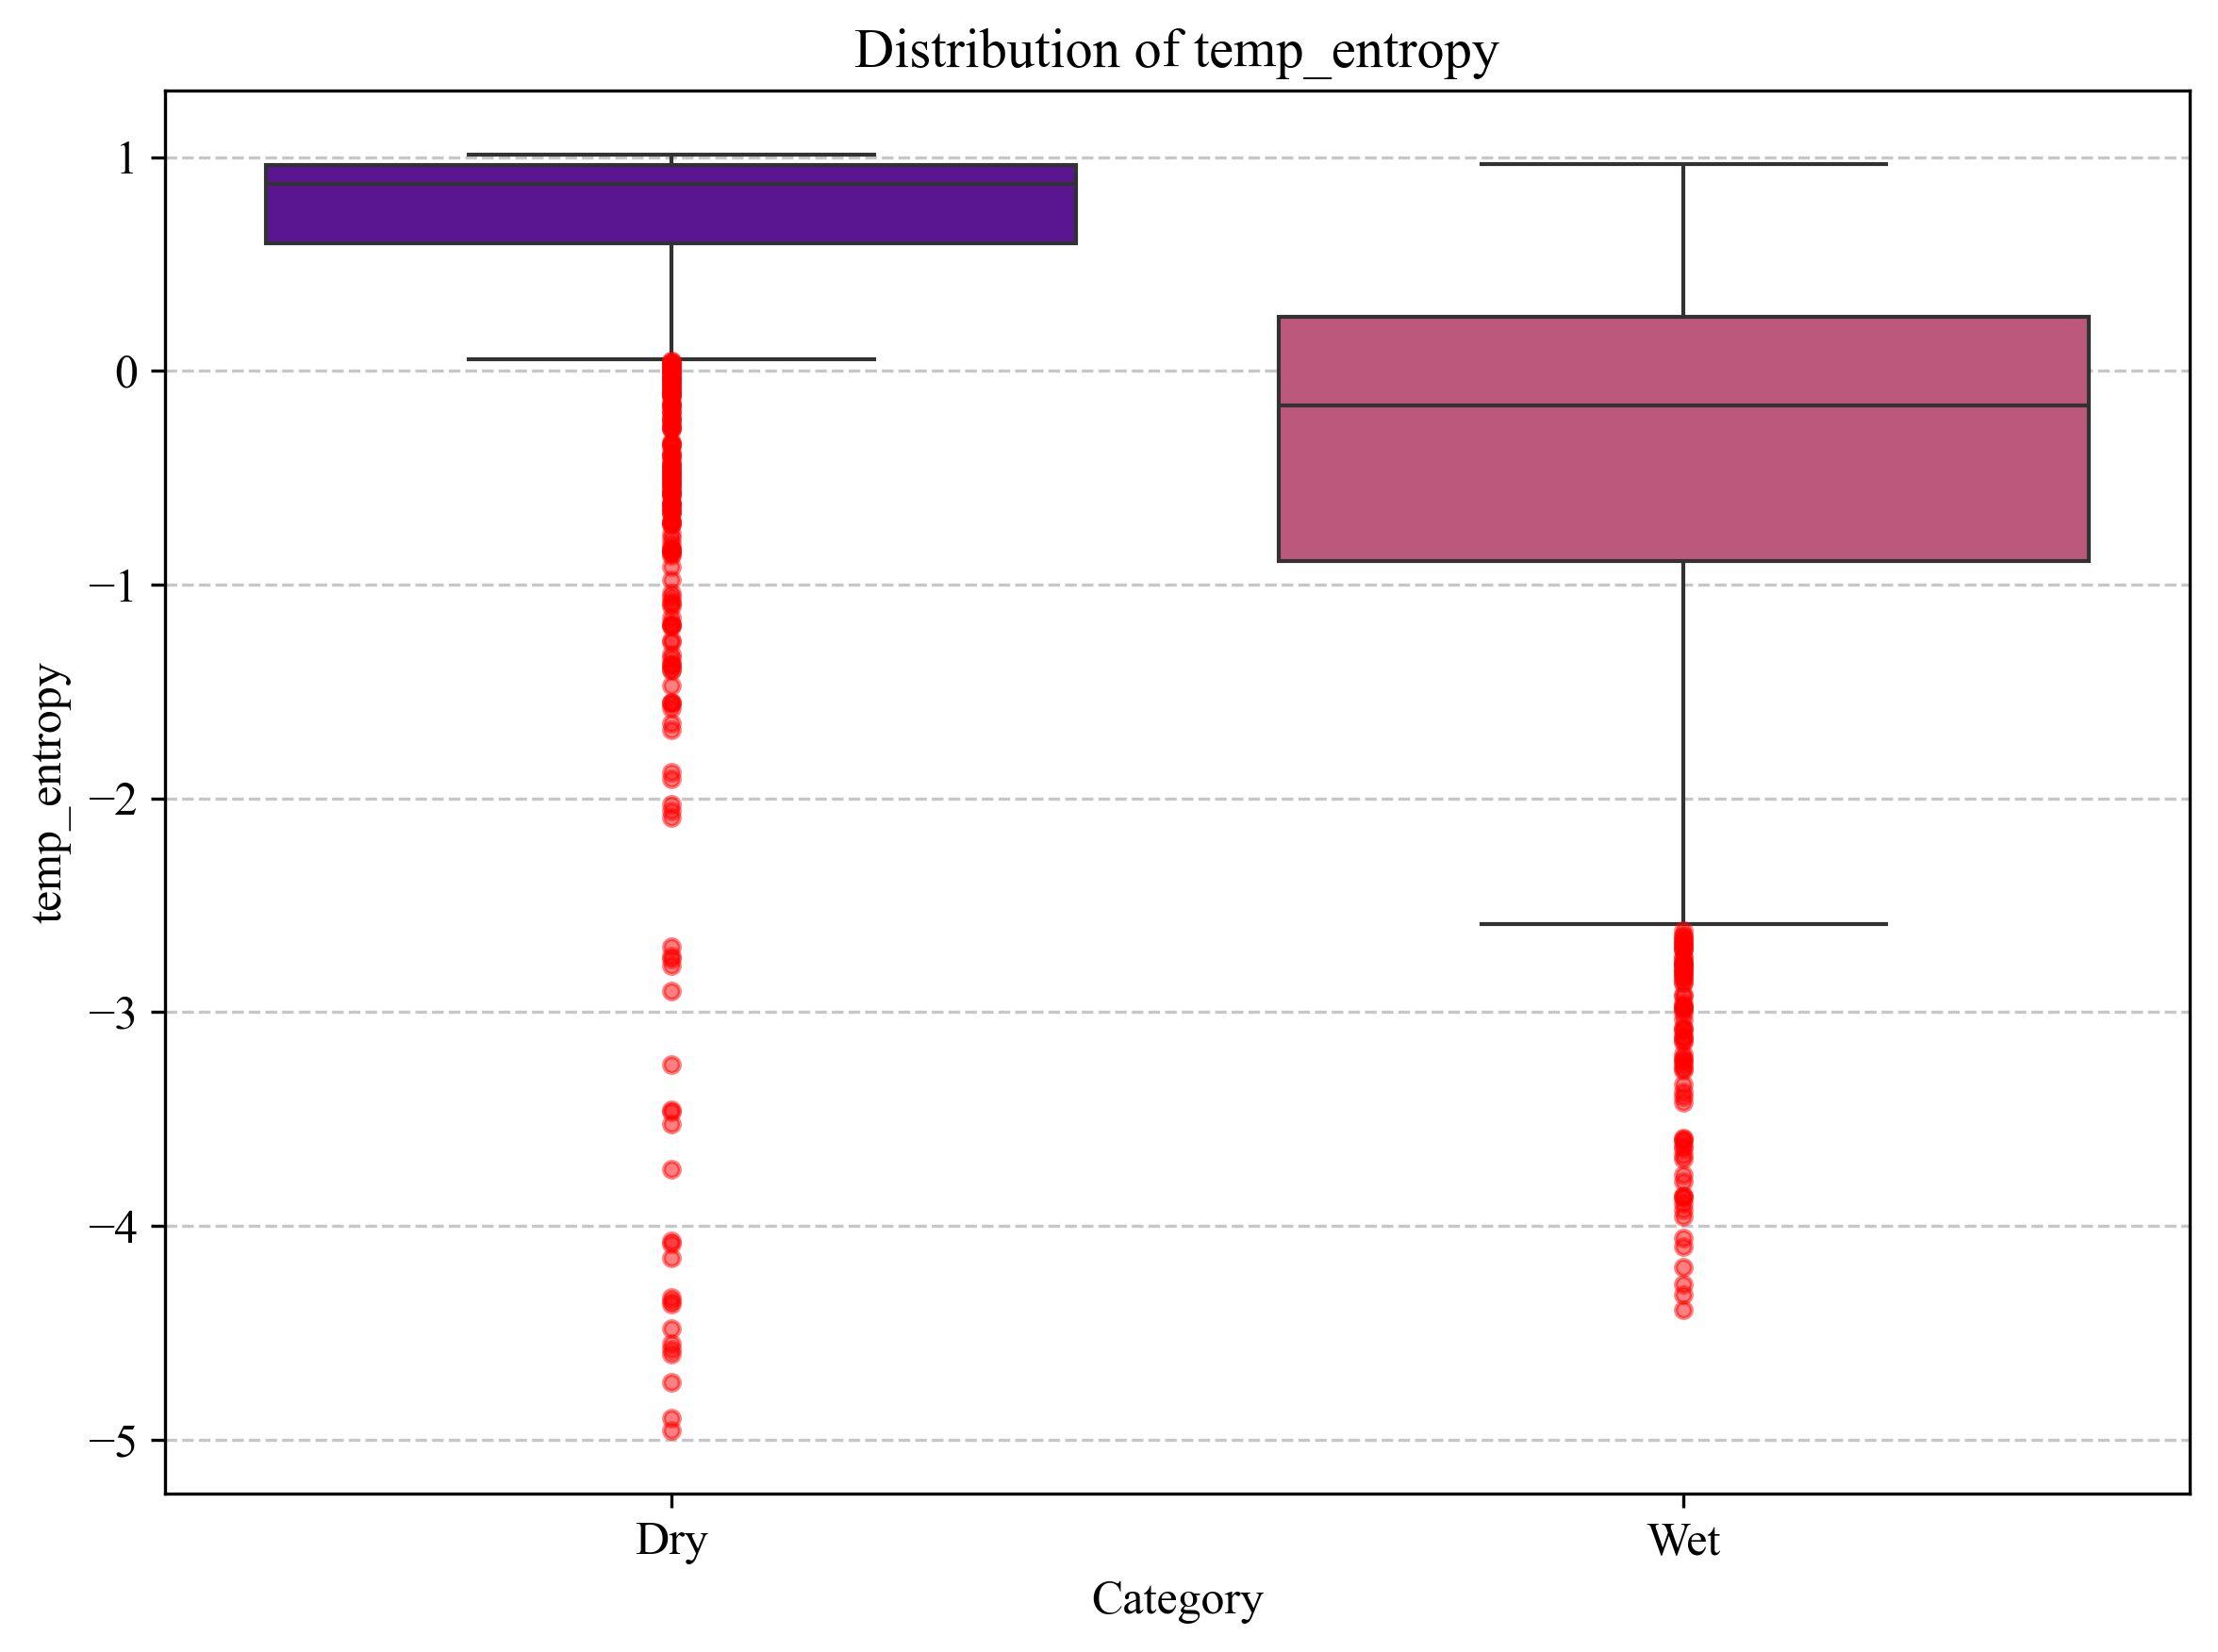

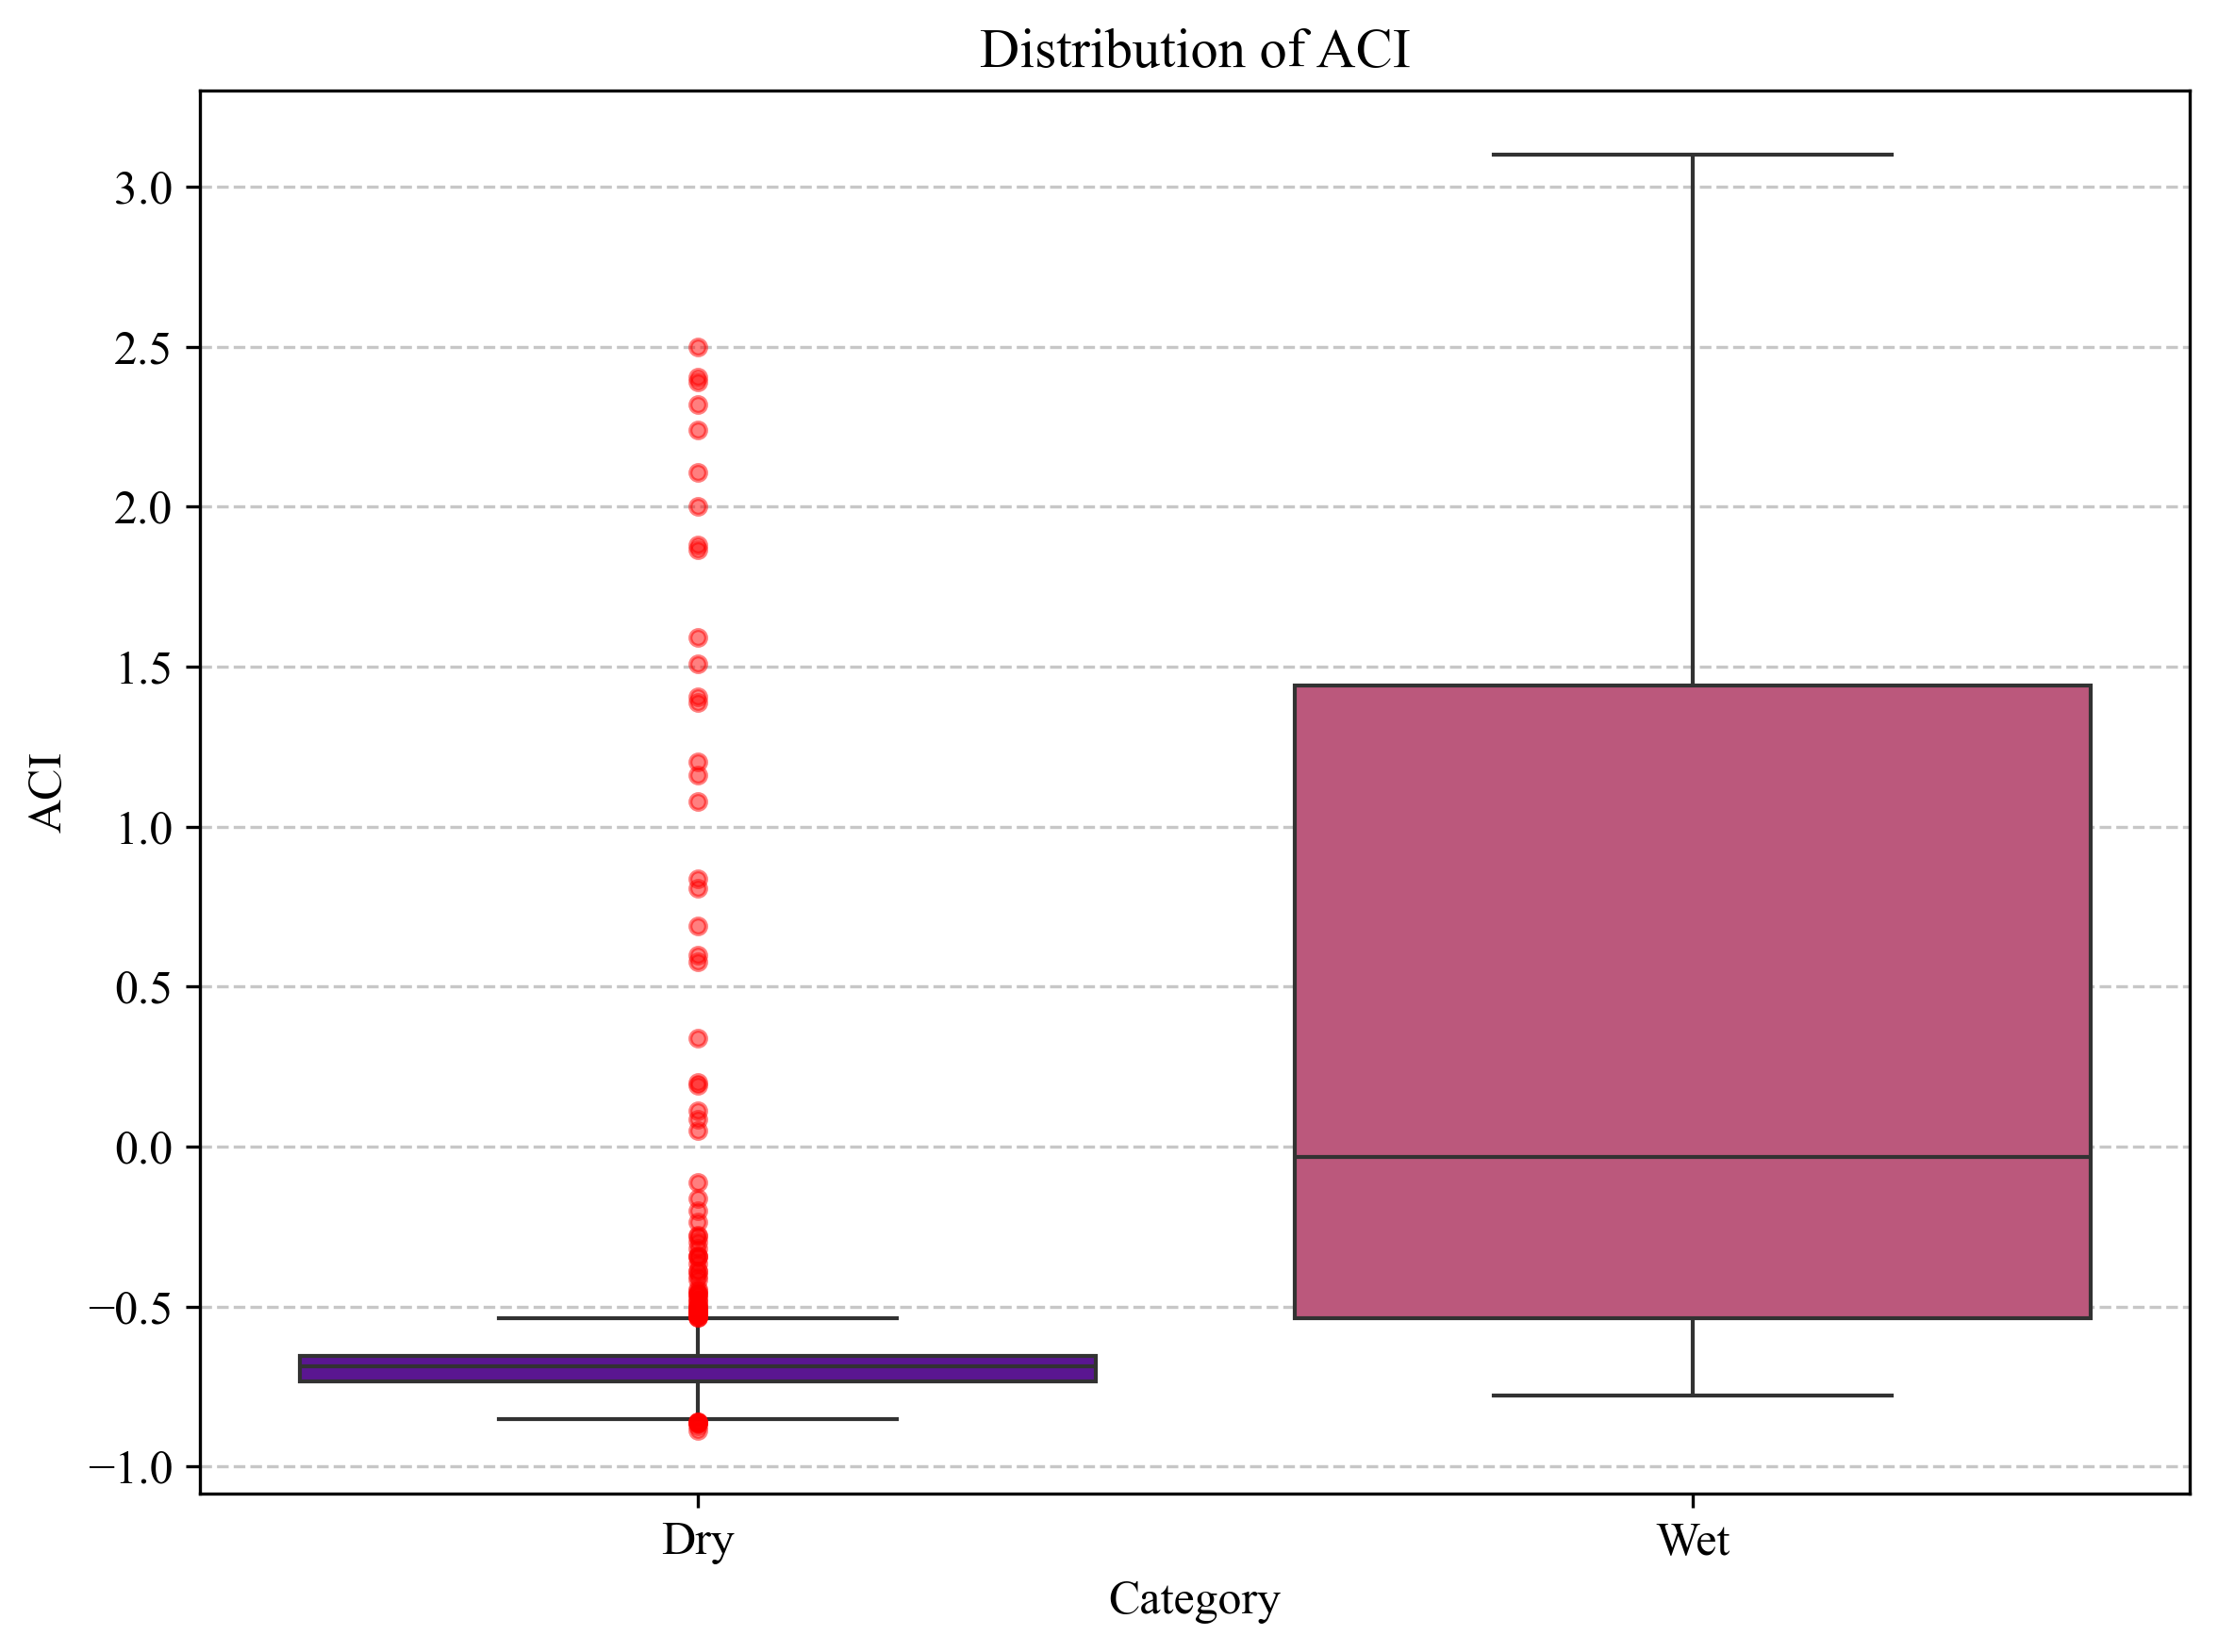

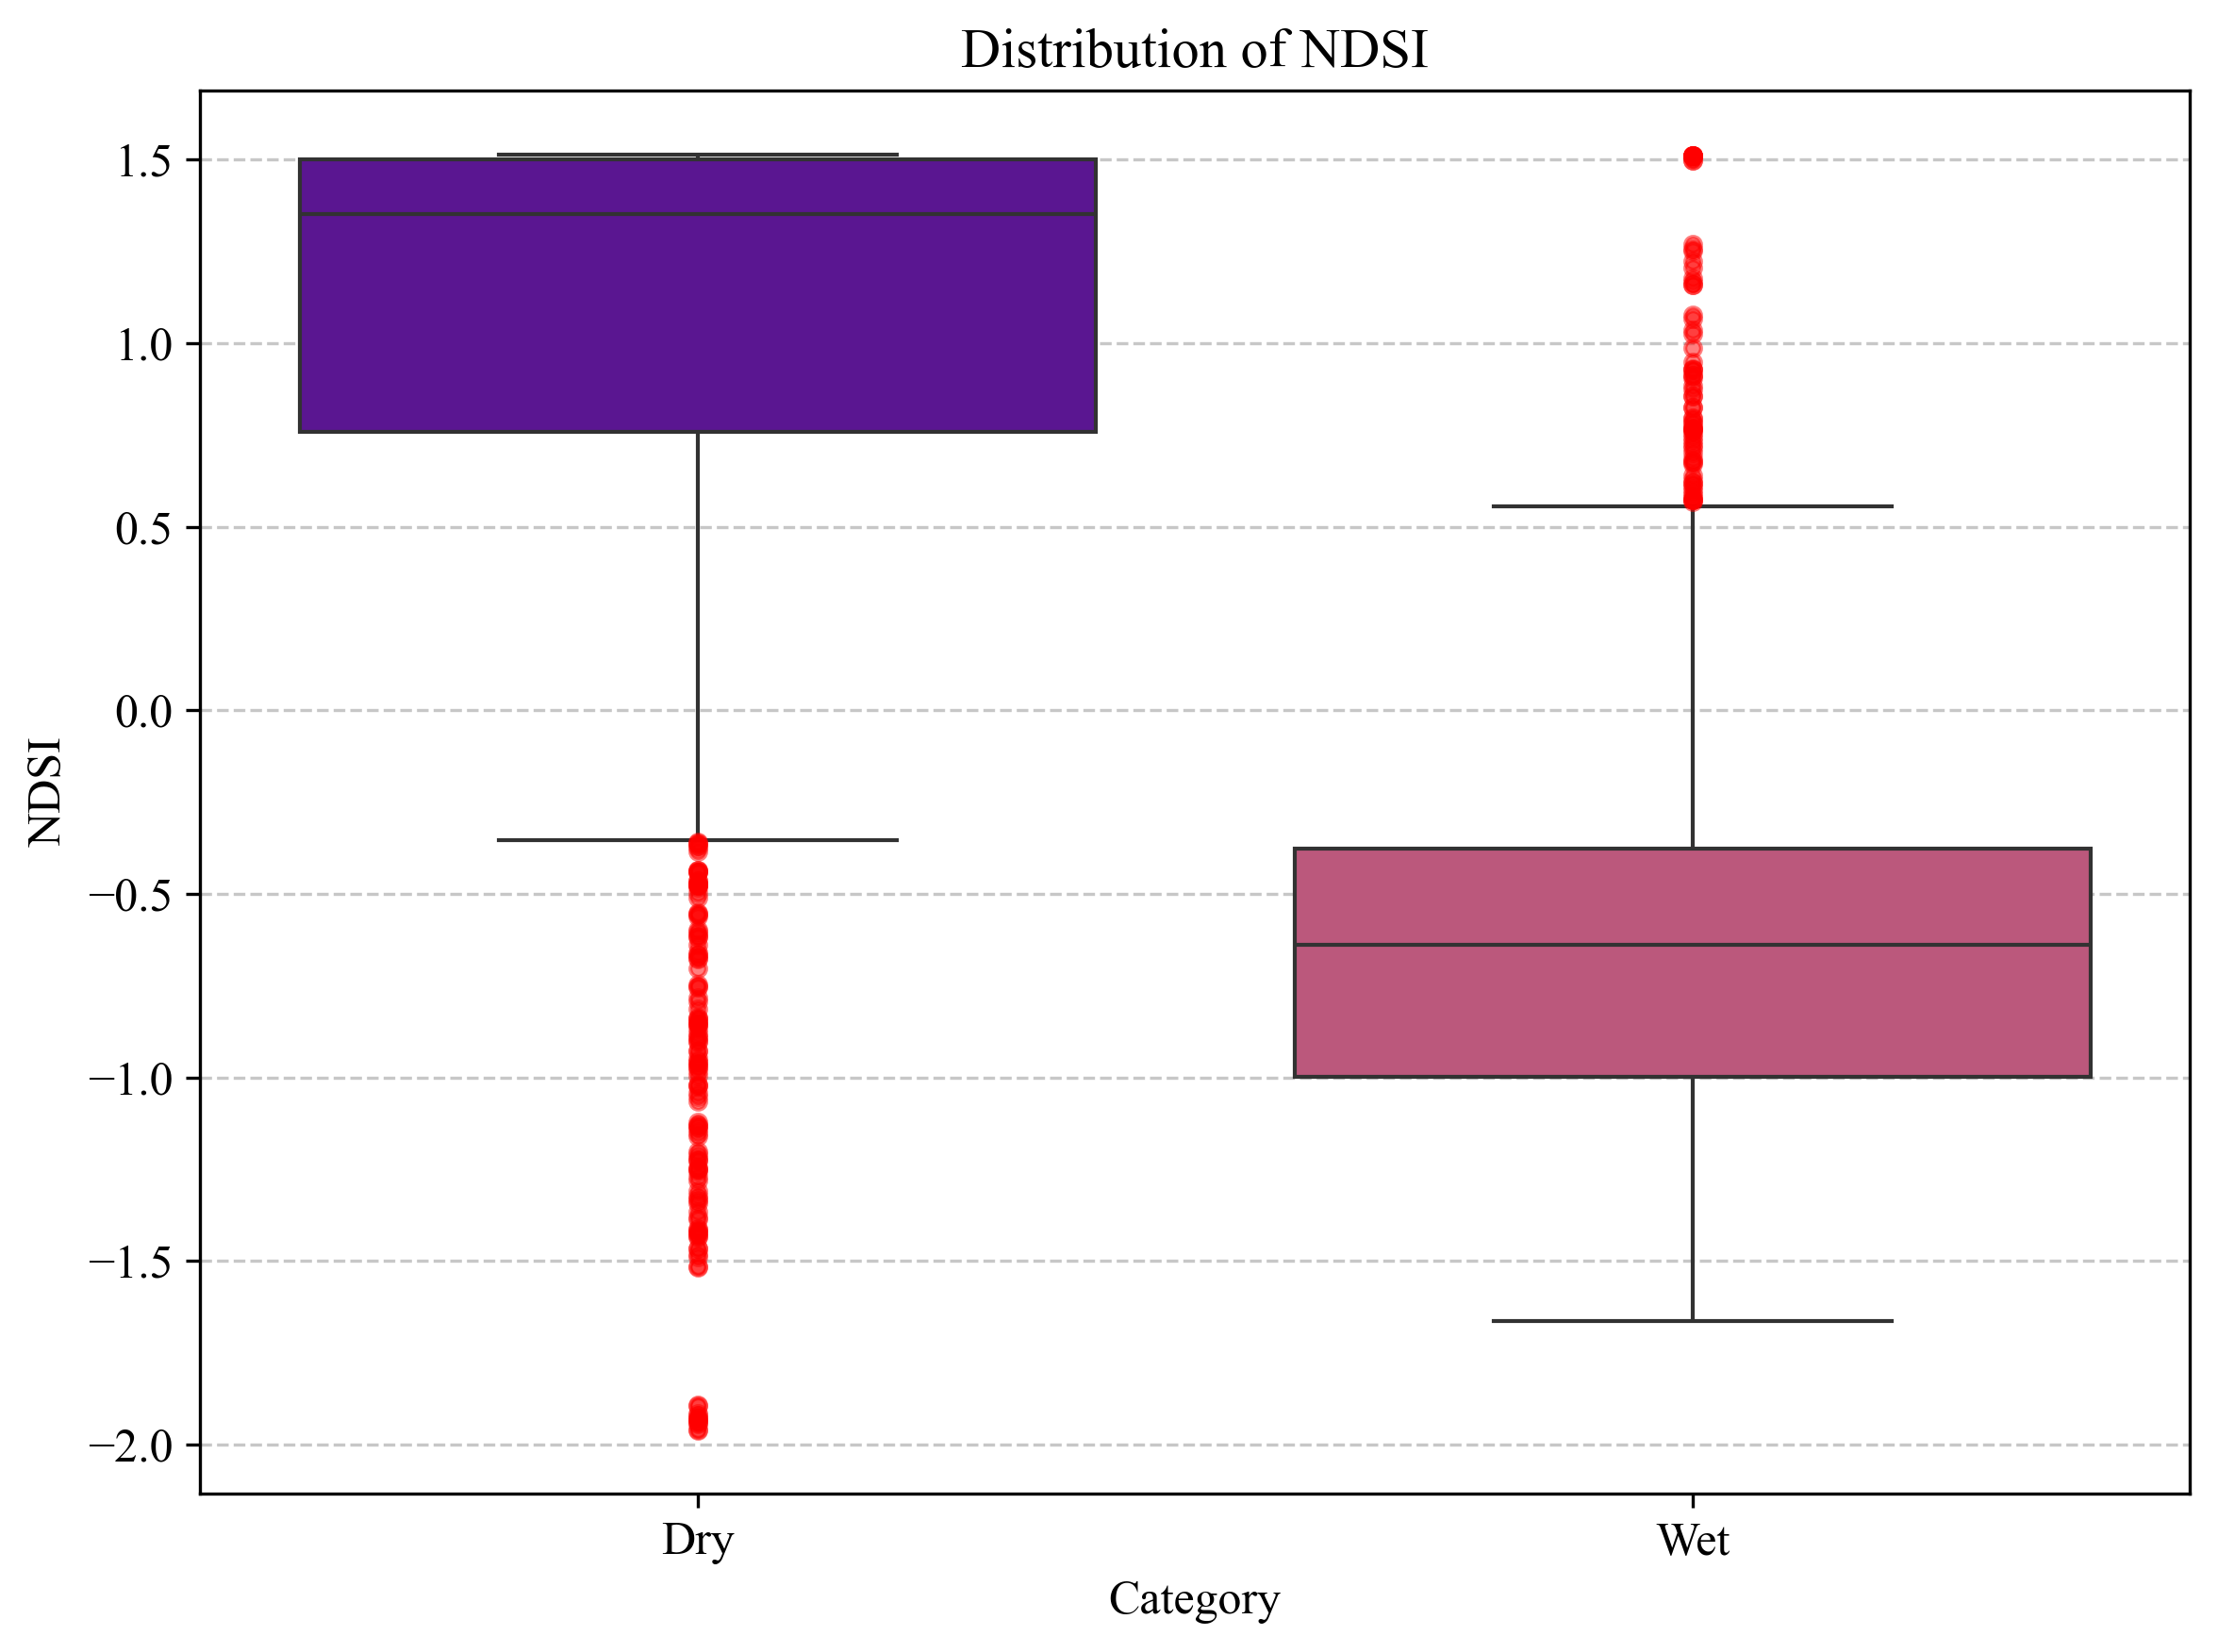

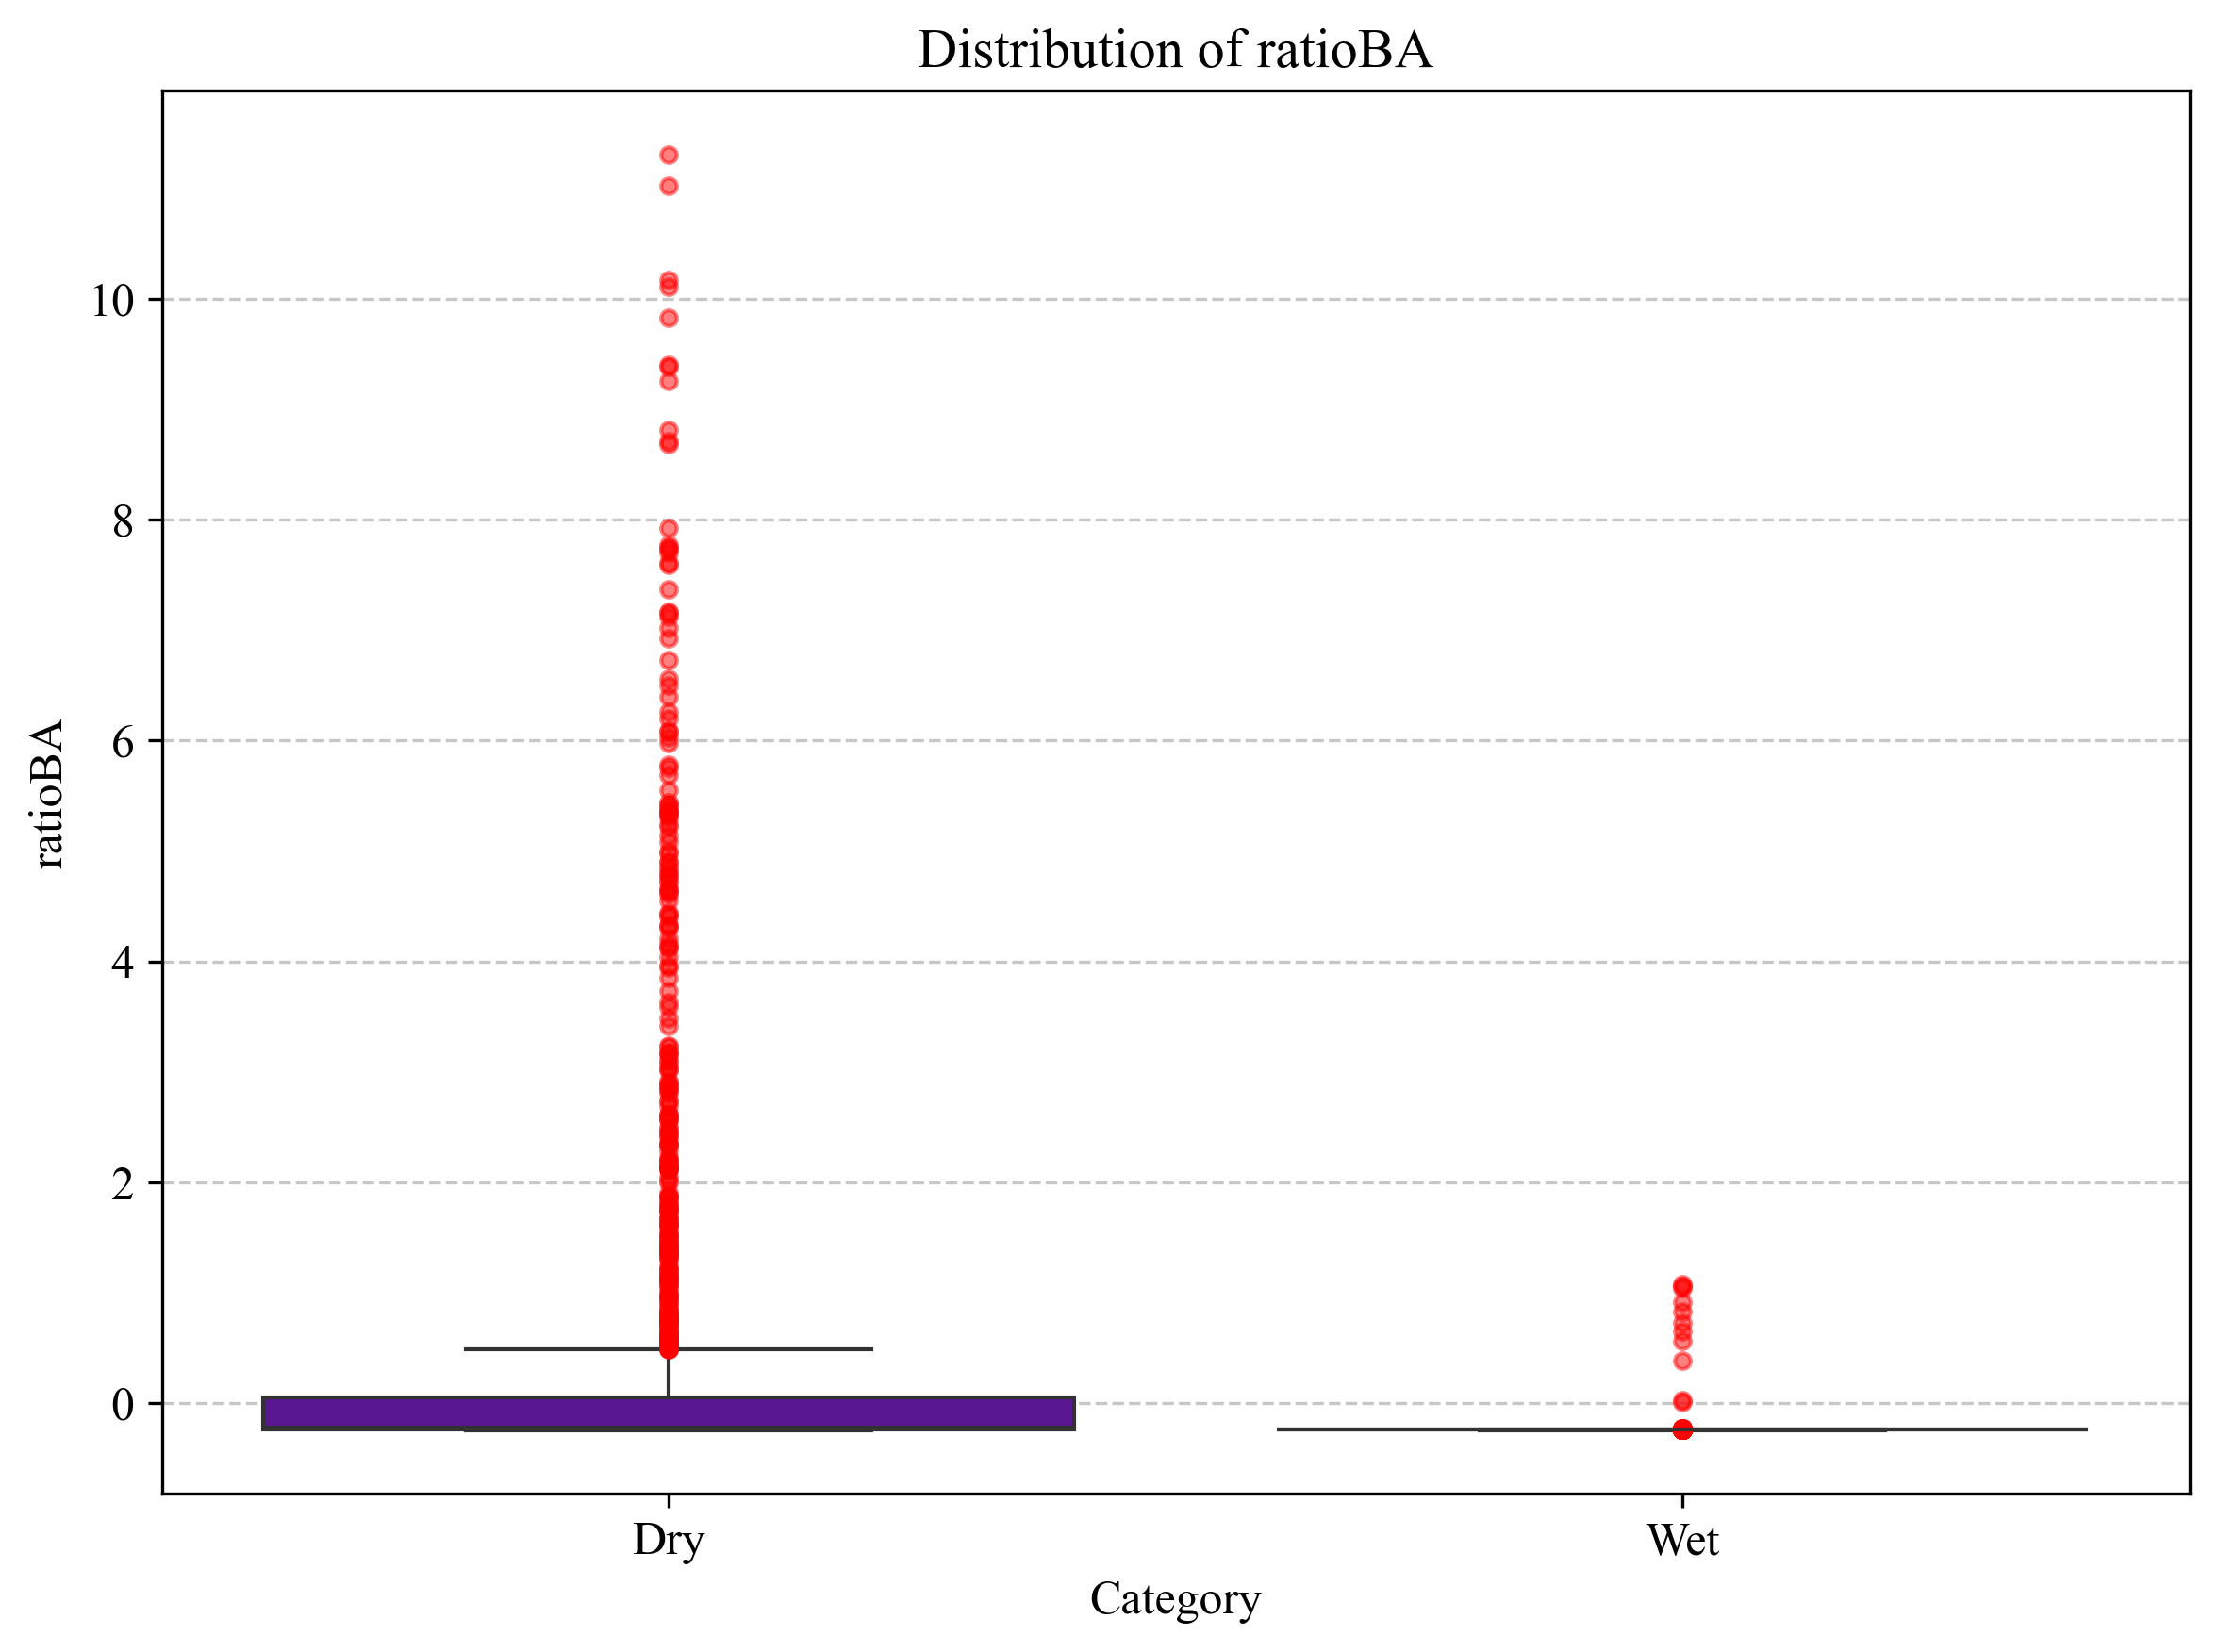

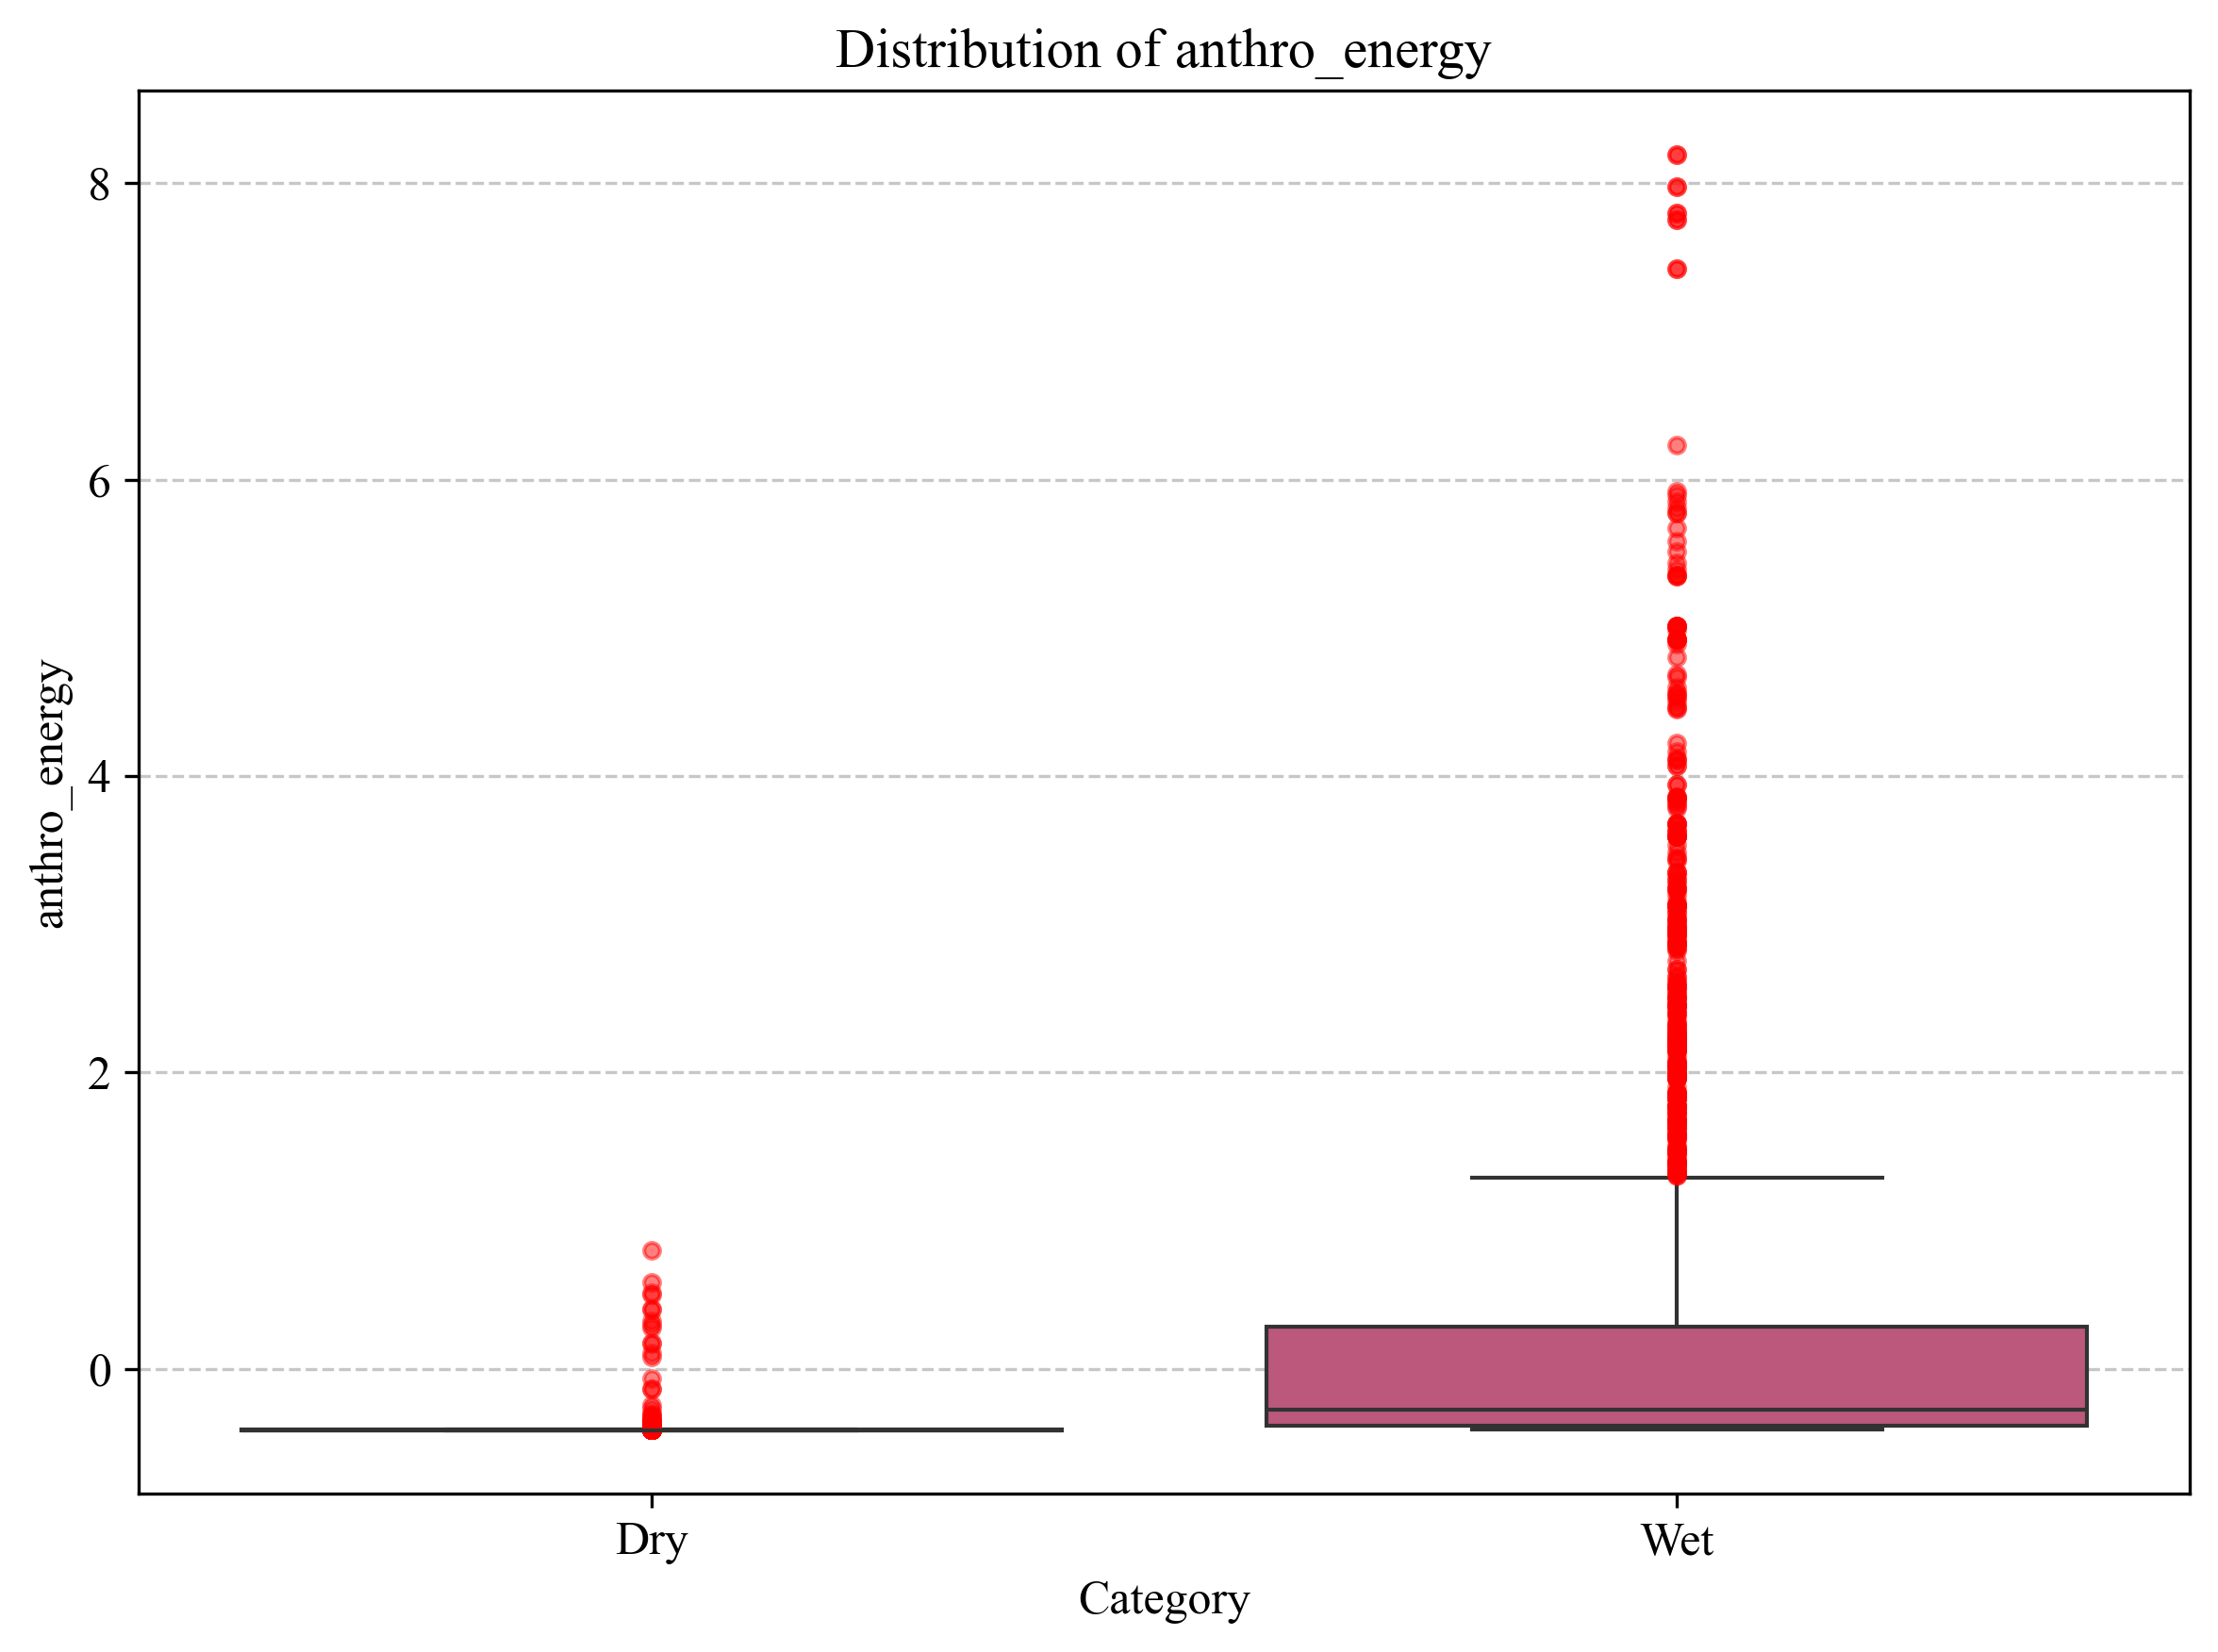

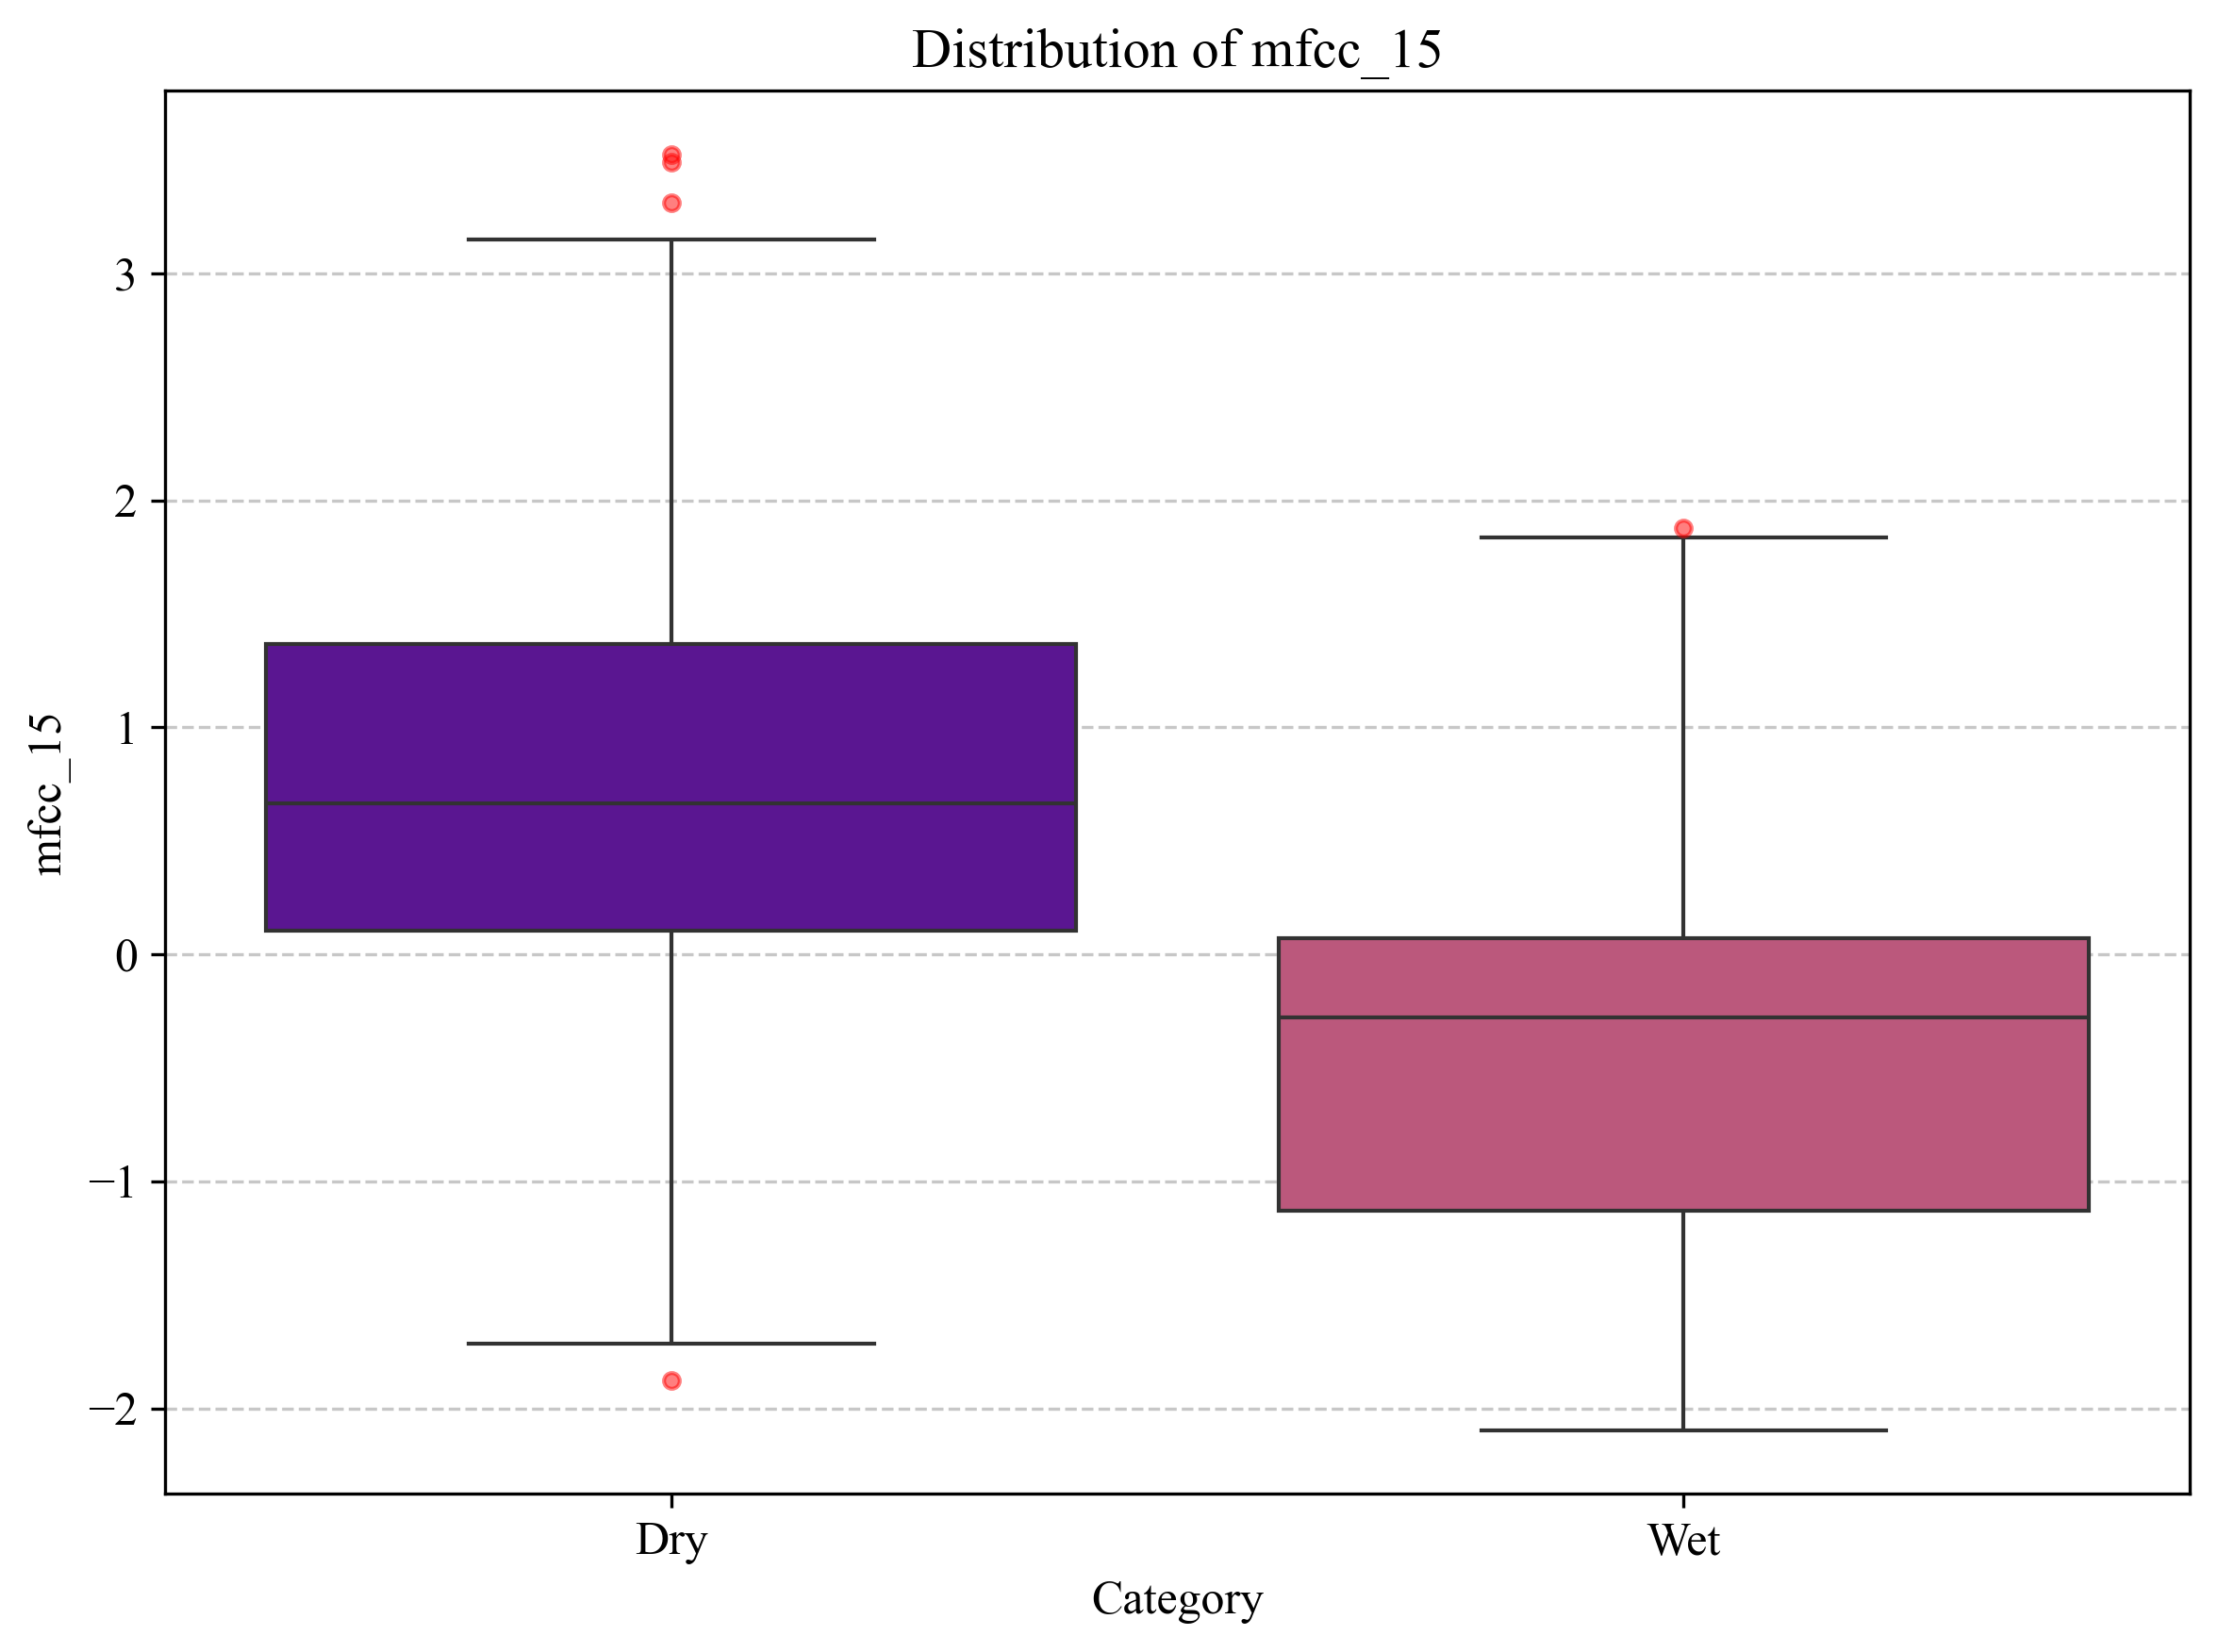

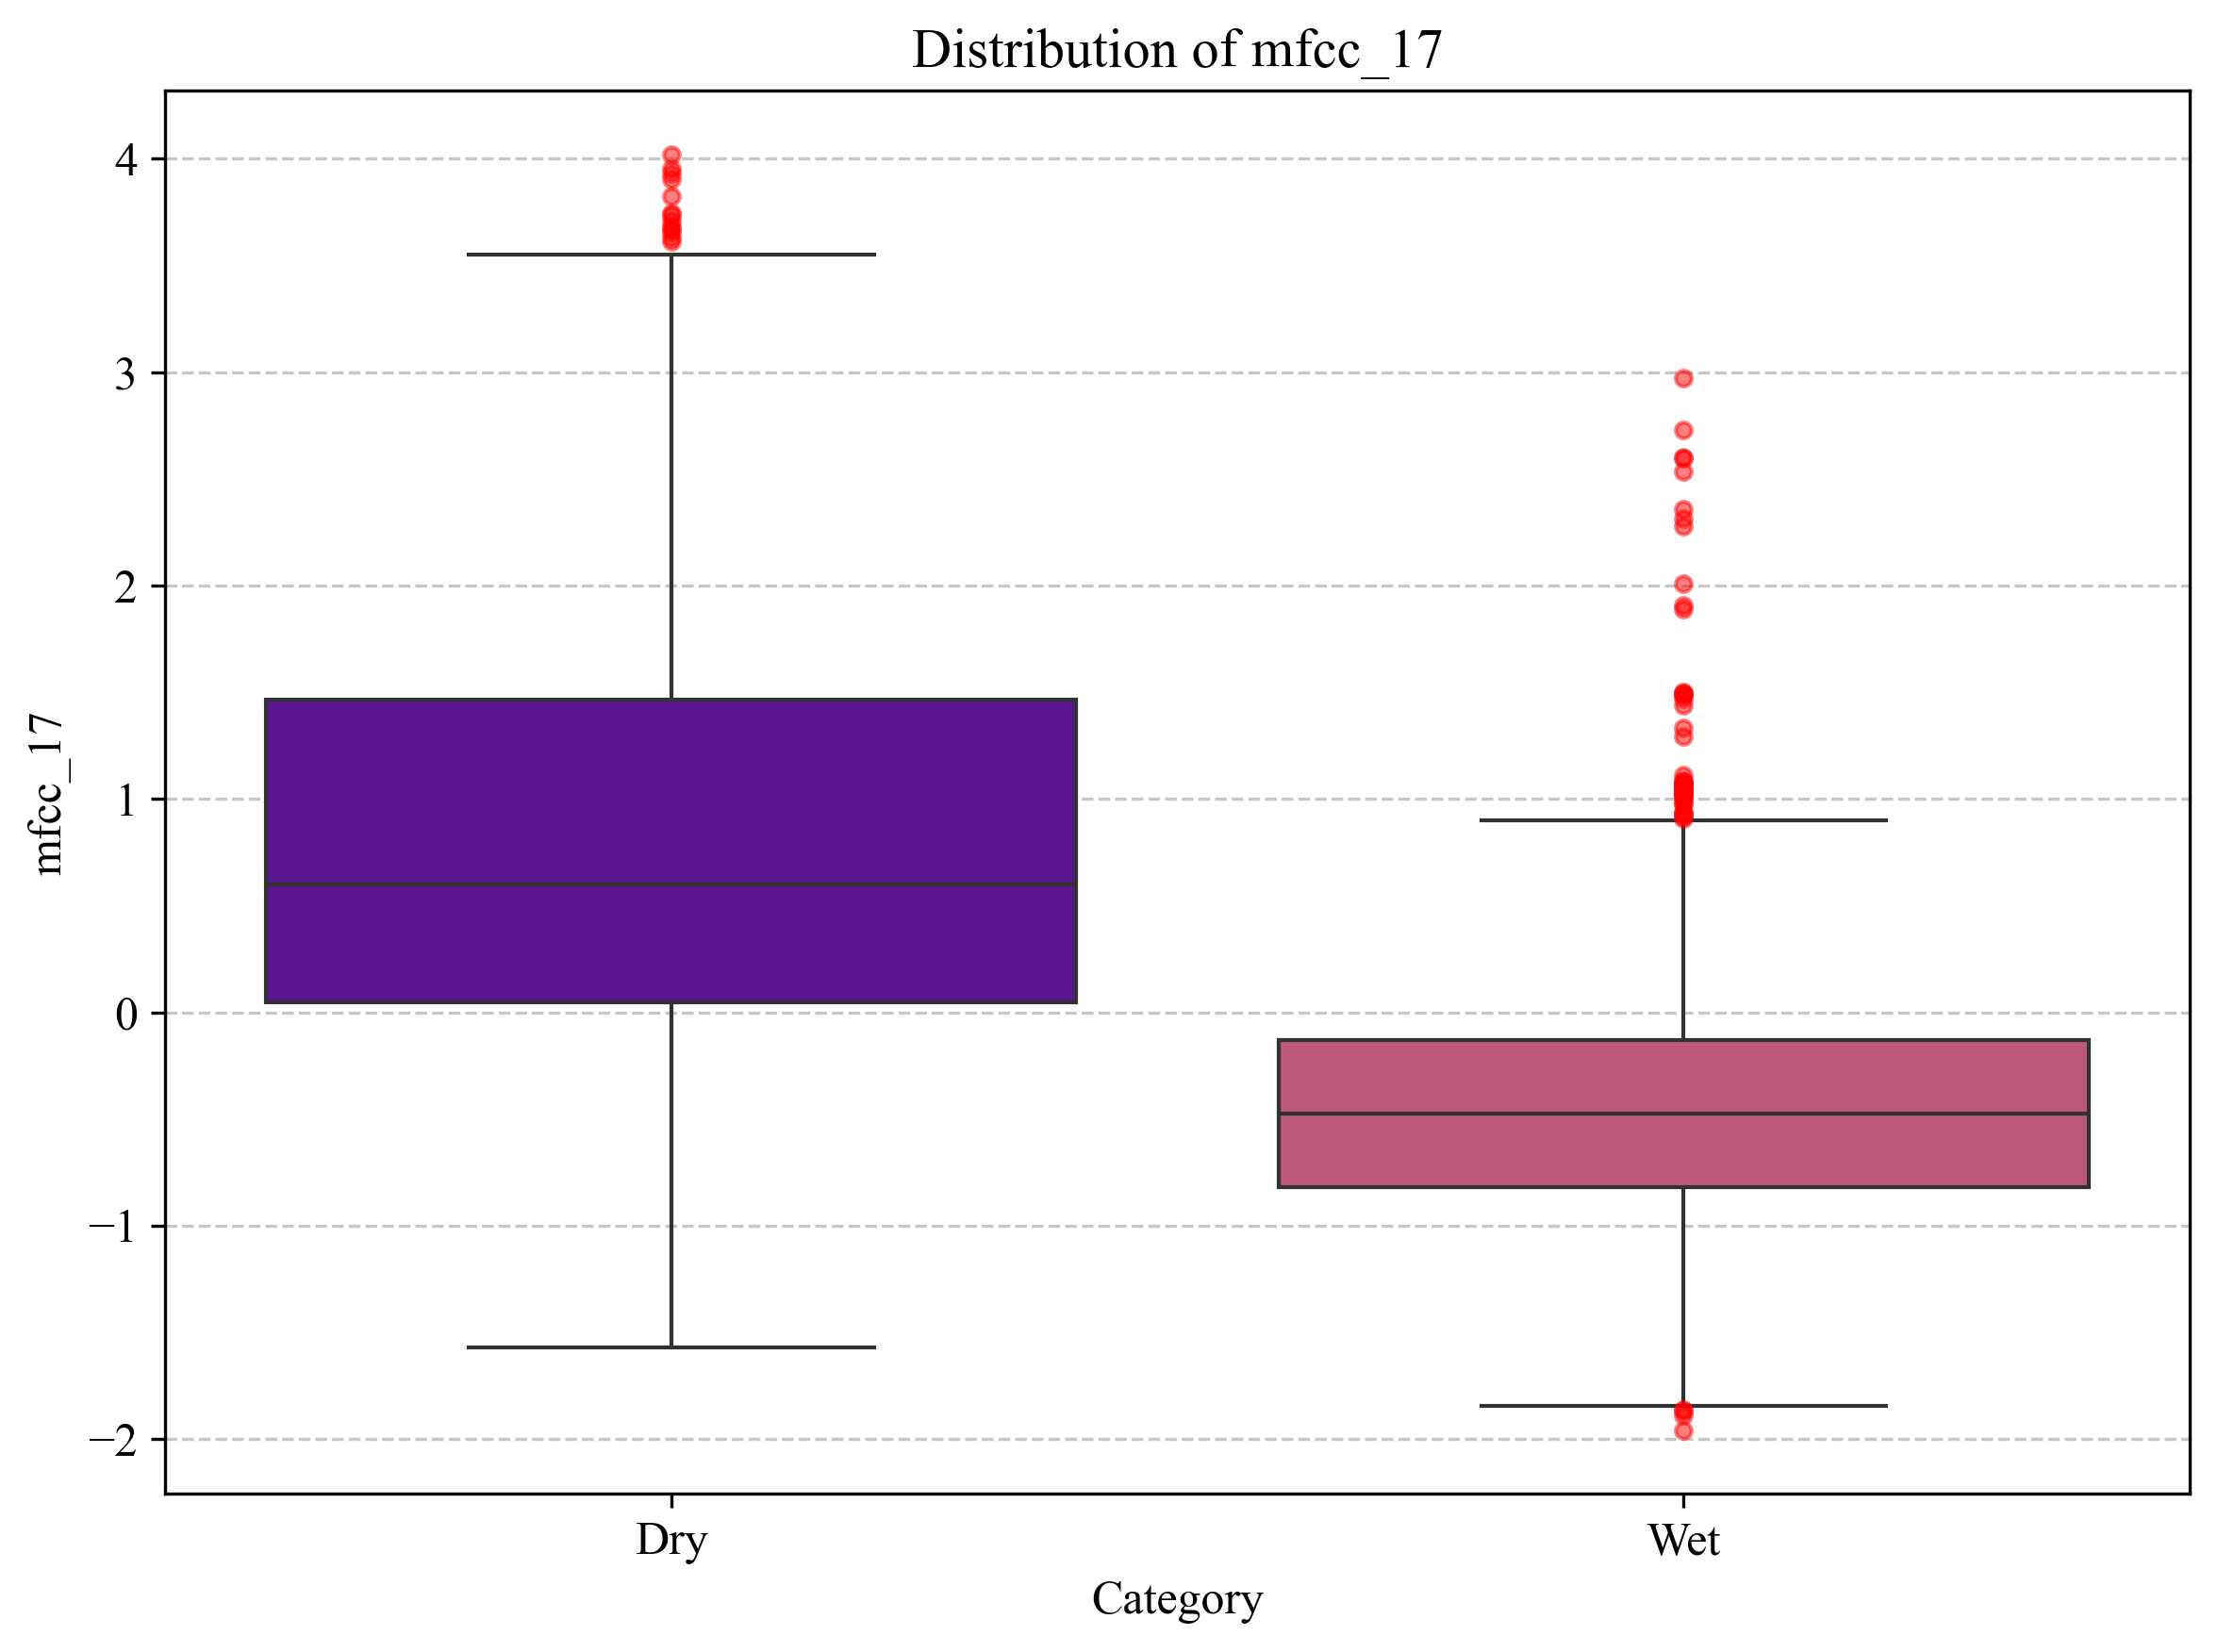

In [4]:
# ==============================================================================
# CELL 4: FEATURE ENGINEERING PLOTS (A JORNADA DO DADO)
# ==============================================================================
import numpy as np
from rainfall_acoustic_classification.feature_engineering.plots import (
    plot_correlation_heatmap,
    plot_feature_importance,
    plot_individual_boxplots,
    plot_fisher_scores,
    plot_selection_rationale # Certifique-se de que adicionou esta função no plots.py
)

final_features = X_train_final.columns.tolist()
num_features_finais = len(final_features)

print(f"Iniciando auditoria visual. Features retidas: {num_features_finais}")

# ==============================================================================
# 1. O FILTRO DE REDUNDÂNCIA (Mapa de Calor de Correlação)
# ==============================================================================
print("\n2. Gerando Matriz de Correlação Completa (Destaque para as Sobreviventes)...")
# Usamos X_train_raw para ver o todo, mas plot_correlation_heatmap vai destacar o que sobrou
plot_correlation_heatmap(
    df=X_train_raw,
    threshold=0.85,
    selected_features=final_features,
    title=f"2. Full Feature Correlation (Selected {num_features_finais} in Red/Bold)"
)

# ==============================================================================
# 2. O MOTOR LINEAR (Fisher F-Score)
# ==============================================================================
print("\n1. Extraindo o Coeficiente de Fisher (Poder de Separação Isolada)...")
fisher_step = seletor_pipeline.named_steps['fisher_score']
indice_fisher = list(seletor_pipeline.named_steps.keys()).index('fisher_score')
features_into_fisher = seletor_pipeline[:indice_fisher].transform(X_train_raw).columns.tolist()
fisher_vals = np.nan_to_num(fisher_step.scores_, nan=0.0)

plot_fisher_scores(
    fisher_model=fisher_step,
    feature_names=features_into_fisher,
    top_n=20, 
    title="1. Fisher Score (ANOVA) - Top 20 Linear Separators"
)

# ==============================================================================
# 3. O MOTOR NÃO-LINEAR (Feature Importance Gini)
# ==============================================================================
print("\n3. Extraindo a Importância Gini do Random Forest...")
rf_interno = seletor_pipeline.named_steps['rf_gini'].estimator_
indice_rf = list(seletor_pipeline.named_steps.keys()).index('rf_gini')
features_into_rf = seletor_pipeline[:indice_rf].transform(X_train_raw).columns.tolist()
importancias_reais = rf_interno.feature_importances_

plot_feature_importance(
    rf_model=rf_interno, 
    feature_names=features_into_rf, 
    top_n=len(features_into_rf), 
    title="3. Gini Importance (The Final Non-Linear Cut)"
)

# ==============================================================================
# 4. A SÍNTESE ESTATÍSTICA (O Quadrante de Seleção)
# ==============================================================================
print("\n4. Cruzando Fisher vs Gini (A Justificativa da Seleção)...")
# Mapeia as importâncias do Gini de volta para a lista completa inicial (preenchendo com 0 o que o Collinear dropou)
rf_importances_full = np.zeros(len(features_into_fisher))
for feat, imp in zip(features_into_rf, importancias_reais):
    if feat in features_into_fisher:
        idx = features_into_fisher.index(feat)
        rf_importances_full[idx] = imp

plot_selection_rationale(
    fisher_scores=fisher_vals,
    gini_importances=rf_importances_full,
    feature_names=features_into_fisher,
    selected_mask=final_features,
    title=f"4. Selection Rationale: High F-Score vs High Gini"
)

# ==============================================================================
# 5. A PROVA VISUAL (Boxplots Individuais)
# ==============================================================================
print(f"\n5. Gerando os {num_features_finais} Boxplots Definitivos...")
print("Dica: Estas 7 features são matematicamente únicas e possuem o maior poder discriminativo conjunto.")

plot_individual_boxplots(
    X=X_train_final, 
    y=y_train, 
    color_map=cores_chuva, 
    class_order=list(y_train.unique())
)